# TP II: Predicción de puntuación y capitalización en texto normalizado

Importamos librerías y fijamos la semilla.

In [1]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import regex
import random
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
import spacy
import torch.nn as nn

import pickle 
from functools import partial 
random.seed(2003)

c:\Users\Florencia\anaconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Arrancamos importando los datos de Wikimedia

In [2]:
dataset = load_dataset("wikimedia/wikipedia", "20231101.es", split='train[:2000000]')

c:\Users\Florencia\anaconda3\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Florencia\.cache\huggingface\hub\datasets--wikimedia--wikipedia. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Old caching folder C:\Users\Florencia\.cache\huggingface\datasets/wikimedia___wikipedia/20231101.es/0.0.0/b04c8d1c

Definimos funciones que nos serán útiles para chequear que la base que generemos efectivamente tenga preguntas y palabras con mayúsculas (en otras posiciones que no sean la primera), y poder contar cuantos de estos casos hay.

In [3]:
def tiene_pregunta(texto):
    return "¿" in texto or "?" in texto

def mayusculas_no_primera(texto):
    """Encuentra palabras que tienen una mayúscula en una posición distinta a la primera"""
    palabras = regex.findall(r'\b\w+\b', texto)
    return [p for p in palabras if any(c.isupper() for c in p[1:])]

Definimos además funciones que nos ayuden a eliminar instancias que no consideremos útiles o aquellas que puedan confundir a nuestro modelo.

In [4]:
def tiene_pregunta_incompleta(texto):
    """Verifica si hay preguntas incompletas"""
    return texto.count('¿') != texto.count('?')

def tiene_puntuacion_no_deseada(texto):
    """
    Verifica si el texto contiene símbolos, puntuación no deseada,
    dígitos o caracteres no latinos (chinos, árabes, cirílicos, etc.)
    Permitidos: letras latinas con acentos, espacio, punto coma pregunta y comillas (. , ?)
    """
    patron = r"[^A-Za-zÁÉÍÓÚÜÑáéíóúüñ .,¿?]"
    return bool(regex.search(patron, texto))

def tiene_simbolos_dobles(texto):
    """
    Detecta si hay dos o más símbolos de puntuación consecutivos sin letras entre medio.
    Ejemplos que detecta: ¿¿, .., ..., ??, ,, ,?
    """
    # símbolos permitidos
    patron = r"[¿,\.?]{2,}"
    return bool(regex.search(patron, texto))

def termina_con_puntuacion(texto):
    """Verifica que el texto termine con . ó ?"""
    texto = texto.strip()
    return texto and texto[-1] in '.?'

def tiene_saltos_de_linea(texto):
    """Verifica si el texto contiene saltos de línea"""
    return '\n' in texto or '\r' in texto

def tiene_muchas_mayusculas_seguidas(texto, limite=2):
    """
    Detecta si hay demasiadas palabras consecutivas totalmente en MAYÚSCULAS.
    limite = cantidad de palabras mayúsculas seguidas permitidas.
    """
    palabras = texto.split()
    contador = 0

    for p in palabras:
        # Se considera mayúscula si tiene al menos una letra y todas son mayúsculas
        if any(c.isalpha() for c in p) and p == p.upper():
            contador += 1
            if contador >= limite:
                return True
        else:
            contador = 0

    return False

def contiene_url(texto):
    """
    Detecta si el texto contiene URLs o dominios web.
    Busca patrones comunes de URLs.
    """
    patrones_url = [
        r'www\.', 
        r'http[s]?://',  
        r'\.(com|org|net|edu|gov|es|ar|mx|cl|co|pe|ve|br)\b', 
        r'://',  
    ]

    texto_lower = texto.lower()
    for patron in patrones_url:
        if regex.search(patron, texto_lower):
            return True
    return False

def es_parrafo_valido(texto):
    """
    LA FUNCION: valida que el parrafo cumpla con los criterios de limpieza.
    Si no los cumple posteriormente serán descartados
    """
    if tiene_pregunta_incompleta(texto):
        return False
    if tiene_simbolos_dobles(texto):
        return False
    if not termina_con_puntuacion(texto):
        return False
    if tiene_puntuacion_no_deseada(texto):
        return False
    if tiene_saltos_de_linea(texto):
        return False
    if contiene_url(texto):
        return False
    if tiene_muchas_mayusculas_seguidas(texto):
        return False
    return True

def es_parte_valida(texto):
    """
    LA FUNCION: valida que la parte cumpla con los criterios de limpieza.
    Si no los cumple posteriormente serán descartados
    """
    if tiene_puntuacion_no_deseada(texto):
        return False
    if tiene_simbolos_dobles(texto):
        return False
    if tiene_saltos_de_linea(texto):
        return False
    if contiene_url(texto):
        return False
    if tiene_muchas_mayusculas_seguidas(texto):
        return False
    return True

def partir_en_dos_random(texto):
    """
    Corta una oración en dos partes aleatorias.
    Mantiene al menos 3 palabras en cada parte.
    """
    palabras = texto.split()
    if len(palabras) < 6:   # mínimo para dos partes razonables
        return []

    # punto de corte aleatorio pero seguro
    corte = random.randint(3, len(palabras) - 3)

    parte1 = " ".join(palabras[:corte])
    parte2 = " ".join(palabras[corte:])

    return [parte1, parte2]

Ahora si, descargamos aquellos artículos cuyo texto contenga al menos 300 characteres y alguna pregunta.

In [5]:
# Filtrar artículos que tengan contenido y al menos una pregunta
articulos_validos = []
for item in dataset:
    texto = item['text']
    if len(texto) > 300 and tiene_pregunta(texto):
        articulos_validos.append({
            'titulo': item['title'],
            'texto': texto
        })

print(f"Artículos filtrados: {len(articulos_validos)}")

Artículos filtrados: 81382


Decidimos dedicar el 98% de los ARTICULOS para armar instancias con párrafos enteros (que pueden contener una o varias oraciones) y el resto lo usamos para partir oraciones en partes, asi el modelo aprende a clasficar trozos de oraciones.

In [6]:
# Mezclamos aleatoriamente los artículos y dividir en proporciones
random.shuffle(articulos_validos)
total = len(articulos_validos)
n_parrafos = int(total * 0.98)
n_partes = total - n_parrafos  # 2% restante

articulos_parrafos = articulos_validos[:n_parrafos]
articulos_partes = articulos_validos[n_parrafos:]

print(f"\nDistribución:")
print(f"- Dataset por párrafos: {len(articulos_parrafos)} artículos")
print(f"- Dataset por partes: {len(articulos_partes)} artículos")

# Contadores y chequeos
total_preguntas = 0
parrafos_con_preguntas = []
todas_palabras_mayusculas_no_primera = []

# DATASET 1: Por párrafos (máximo 4 oraciones)
print("\n" + "="*60)
print("GENERANDO DATASETS: POR PÁRRAFOS")
print("="*60)
data_parrafos_con_preg = []
data_parrafos_sin_preg = []
rechazados_parrafos = 0

for articulo in articulos_parrafos:
    parrafos = [p.strip() for p in articulo['texto'].split('\n') if p.strip()]

    for parrafo in parrafos:
        # dividimos en oraciones
        oraciones = regex.split(r'(?<=[.?])\s+', parrafo)
        # Cortams el parrafo a 4 oraciones
        if len(oraciones) > 4:
            # nos quedamos  con las primeras 4 oraciones
            parrafo = " ".join(oraciones[:4])

        # Se conserva solo si tiene entre 10 y 50 palabras
        if 10 <= len(parrafo.split()) <= 50:
            if not es_parrafo_valido(parrafo):
                rechazados_parrafos += 1
                continue

            instancia = {
                'titulo': articulo['titulo'],
                'texto': parrafo
            }

            # Separamos según tenga o no preguntas
            if tiene_pregunta(parrafo):
                data_parrafos_con_preg.append(instancia)
                total_preguntas += parrafo.count('?')
                if len(parrafos_con_preguntas) < 7:
                    parrafos_con_preguntas.append(parrafo[:300])
            else:
                data_parrafos_sin_preg.append(instancia)

            palabras_multi = mayusculas_no_primera(parrafo)
            todas_palabras_mayusculas_no_primera.extend(palabras_multi)

print(f"Instancias rechazadas por limpieza: {rechazados_parrafos}")
print(f"Párrafos CON preguntas: {len(data_parrafos_con_preg)}")
print(f"Párrafos SIN preguntas: {len(data_parrafos_sin_preg)}")

# DATASET 2: Partes random
print("\n" + "="*60)
print("GENERANDO DATASETS: PARTES DE ORACIÓN")
print("="*60)
data_partes_con_preg = []
data_partes_sin_preg = []
rechazados_partes = 0

for articulo in articulos_partes:
    oraciones = regex.split(r'(?<=[.!?])\s+', articulo['texto'])

    for oracion in oraciones:
        oracion = oracion.strip()
        if len(oracion) > 30:

            partes = partir_en_dos_random(oracion)
            if not partes:
                continue
            # Consideramos que las oraciones cortadas serán solo desde el principio:
            parte = partes[0]  # Nos quedamos solo con la primer parte

            if not es_parte_valida(parte):
                rechazados_partes += 1
                continue

            instancia = {
                'titulo': articulo['titulo'],
                'texto': parte
            }

            # Separamos según tenga o no preguntas
            if tiene_pregunta(parte):
                data_partes_con_preg.append(instancia)
                total_preguntas += parte.count('?')
                if len(parrafos_con_preguntas) < 7:
                    parrafos_con_preguntas.append(parte[:300])
            else:
                data_partes_sin_preg.append(instancia)

            palabras_multi = mayusculas_no_primera(parte)
            todas_palabras_mayusculas_no_primera.extend(palabras_multi)

print(f"Instancias rechazadas por limpieza: {rechazados_partes}")
print(f"Partes CON preguntas: {len(data_partes_con_preg)}")
print(f"Partes SIN preguntas: {len(data_partes_sin_preg)}")

# Guardar los 4 datasets
df_parrafos_con_preg = pd.DataFrame(data_parrafos_con_preg)
df_parrafos_sin_preg = pd.DataFrame(data_parrafos_sin_preg)
df_partes_con_preg = pd.DataFrame(data_partes_con_preg)
df_partes_sin_preg = pd.DataFrame(data_partes_sin_preg)

print("\n" + "="*60)
print("ESTADÍSTICAS FINALES")
print("="*60)
print(f"\nDataset párrafos CON preguntas: {len(df_parrafos_con_preg)} instancias")
print(f"Dataset párrafos SIN preguntas: {len(df_parrafos_sin_preg)} instancias")
print(f"Dataset partes CON preguntas: {len(df_partes_con_preg)} instancias")
print(f"Dataset partes SIN preguntas: {len(df_partes_sin_preg)} instancias")
print(f"TOTAL: {len(df_parrafos_con_preg) + len(df_parrafos_sin_preg) + len(df_partes_con_preg) + len(df_partes_sin_preg)} instancias")


Distribución:
- Dataset por párrafos: 79754 artículos
- Dataset por partes: 1628 artículos

GENERANDO DATASETS: POR PÁRRAFOS
Instancias rechazadas por limpieza: 1051388
Párrafos CON preguntas: 1816
Párrafos SIN preguntas: 168957

GENERANDO DATASETS: PARTES DE ORACIÓN
Instancias rechazadas por limpieza: 39241
Partes CON preguntas: 214
Partes SIN preguntas: 56218

ESTADÍSTICAS FINALES

Dataset párrafos CON preguntas: 1816 instancias
Dataset párrafos SIN preguntas: 168957 instancias
Dataset partes CON preguntas: 214 instancias
Dataset partes SIN preguntas: 56218 instancias
TOTAL: 227205 instancias


In [7]:
# imprimimos algunos ejemplos para chequear
print(f"\nPREGUNTAS ENCONTRADAS: {total_preguntas}")
print(f"\nEjemplos de textos con preguntas (mostrando {len(parrafos_con_preguntas)}):")
print("-" * 60)
for i, parrafo in enumerate(parrafos_con_preguntas, 1):
    print(f"\n{i}. {parrafo}...")

palabras_unicas = list(set(todas_palabras_mayusculas_no_primera))
print(f"\nPALABRAS CON MAYÚSCULAS NO PRIMERAS: {len(palabras_unicas)} únicas")
print(f"\nMostrando algunas:")
print("-" * 60)
for i, palabra in enumerate(palabras_unicas[:50], 1):
    print(f"{palabra}", end="  ")
    if i % 10 == 0:
        print()


PREGUNTAS ENCONTRADAS: 2162

Ejemplos de textos con preguntas (mostrando 7):
------------------------------------------------------------

1. Aparece la condesa, buscando al Caballero. No está contenta cuando Don Profondo le dice que está rcibiendo una lección de poesía. Don Álvaro y el conde Libenskof se unen a ellos, preguntando por los caballos, y el barón, también, aparece, pareciendo angustiado. ¿Qué ha ocurrido?...

2. ¿Quién es tan amplio como para abarcar el mundo entero?...

3. ¿No habrá absolutamente ninguna restricción sobre las formas de tenencia de la tierra? Hogares, granjas, comunidades o cooperativas, según se decida en cada aldea y asentamiento....

4. En lo que conforma la introducción al texto, el autor plantea las interrogantes alrededor de lo que él denomina estrategias para entrar y salir de la modernidad, pues las tradiciones aún no se han ido y la modernidad no acaba de llegar, ¿es obligatorio modernizarnos?...

5. ¿Cuántas millas en total conducen los norteame

Una vez que tenemos las distintas bases con instancias como parrafos o partes de texto (con o sin preguntas), tenemos que armar propiamente las instancias como nos sirven para entrenar a los modelos, es decir, con los tokens como instantes temporales.

In [8]:
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

# Capitalización
def clase_capitalizacion(palabra_original):
    """
    Determina la clase de capitalización de una palabra COMPLETA (sin ##)
    0: todo minúsculas
    1: primera letra mayúscula
    2: mixto (algunas mayúsculas)
    3: todo mayúsculas (más de 1 letra)
    """
    if not palabra_original:
        return 0

    # total minúsculas
    if palabra_original.islower():
        return 0

    # primera mayúscula, resto minúsculas (incluye palabras de 1 letra)
    if len(palabra_original) == 1 and palabra_original.isupper():
        return 1

    if palabra_original[0].isupper() and palabra_original[1:].islower():
        return 1

    # todas mayúsculas (más de 1 letra)
    if len(palabra_original) > 1 and palabra_original.isupper():
        return 3

    # mixtas (McDonalds, iPhone)
    return 2


def texto_a_df_token(df_total):
    # Crear instancia_id si no existe
    if "instancia_id" not in df_total.columns:
        df_total = df_total.copy()
        df_total["instancia_id"] = df_total.index + 1

    resultado = []

    for idx, row in df_total.iterrows():

        instancia_id = row["instancia_id"]
        texto = row["texto"]

        i = 0
        elementos = []
        palabra_actual = ""
        punt_inicial_acumulada = ""

        while i < len(texto):
            char = texto[i]

            if char in ['¿', ',', '.', '?']:
                if palabra_actual.strip():
                    elementos.append({
                        'tipo': 'palabra',
                        'contenido': palabra_actual.strip(),
                        'punt_inicial': punt_inicial_acumulada,
                        'punt_final': ''
                    })
                    palabra_actual = ""
                    punt_inicial_acumulada = ""

                if char == '¿':
                    punt_inicial_acumulada = char
                else:
                    if elementos and elementos[-1]['tipo'] == 'palabra':
                        elementos[-1]['punt_final'] = char

            elif char == ' ':
                if palabra_actual.strip():
                    elementos.append({
                        'tipo': 'palabra',
                        'contenido': palabra_actual.strip(),
                        'punt_inicial': punt_inicial_acumulada,
                        'punt_final': ''
                    })
                    palabra_actual = ""
                    punt_inicial_acumulada = ""

            else:
                palabra_actual += char

            i += 1

        if palabra_actual.strip():
            elementos.append({
                'tipo': 'palabra',
                'contenido': palabra_actual.strip(),
                'punt_inicial': punt_inicial_acumulada,
                'punt_final': ''
            })

        for elemento in elementos:
            if elemento["tipo"] != "palabra":
                continue

            palabra_original = elemento["contenido"]
            texto_sin_cap = palabra_original.lower()
            tokens = tokenizer.tokenize(texto_sin_cap)
            cap = clase_capitalizacion(palabra_original)

            for j, tok in enumerate(tokens):
                token_id = tokenizer.convert_tokens_to_ids(tok)

                pi = elemento["punt_inicial"] if j == 0 else ""
                pf = elemento["punt_final"] if j == len(tokens) - 1 else ""

                resultado.append({
                    "instancia_id": instancia_id,
                    "token_id": token_id,
                    "token": tok,
                    "punt_inicial": pi,
                    "punt_final": pf,
                    "capitalización": cap
                })

        if (idx + 1) % 1000 == 0:
            print(f"Procesadas {idx + 1}/{len(df_total)} instancias...")

    return pd.DataFrame(resultado)

df_parrafos_con_preg_token = texto_a_df_token(df_parrafos_con_preg)
df_parrafos_sin_preg_token = texto_a_df_token(df_parrafos_sin_preg)
df_partes_con_preg_token = texto_a_df_token(df_partes_con_preg)
df_partes_sin_preg_token = texto_a_df_token(df_partes_sin_preg)

df_parrafos_con_preg_token.to_csv("df_parrafos_con_preg_token.csv", index=False, encoding="utf-8")
df_parrafos_sin_preg_token.to_csv("df_parrafos_sin_preg_token.csv", index=False, encoding="utf-8")
df_partes_con_preg_token.to_csv("df_partes_con_preg_token.csv", index=False, encoding="utf-8")
df_partes_sin_preg_token.to_csv("df_partes_sin_preg_token.csv", index=False, encoding="utf-8")

c:\Users\Florencia\anaconda3\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Florencia\.cache\huggingface\hub\models--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Procesadas 1000/1816 instancias...
Procesadas 1000/168957 instancias...
Procesadas 2000/168957 instancias...
Procesadas 3000/168957 instancias...
Procesadas 4000/168957 instancias...
Procesadas 5000/168957 instancias...
Procesadas 6000/168957 instancias...
Procesadas 7000/168957 instancias...
Procesadas 8000/168957 instancias...
Procesadas 9000/168957 instancias...
Procesadas 10000/168957 instancias...
Procesadas 11000/168957 instancias...
Procesadas 12000/168957 instancias...
Procesadas 13000/168957 instancias...
Procesadas 14000/168957 instancias...
Procesadas 15000/168957 instancias...
Procesadas 16000/168957 instancias...
Procesadas 17000/168957 instancias...
Procesadas 18000/168957 instancias...
Procesadas 19000/168957 instancias...
Procesadas 20000/168957 instancias...
Procesadas 21000/168957 instancias...
Procesadas 22000/168957 instancias...
Procesadas 23000/168957 instancias...
Procesadas 24000/168957 instancias...
Procesadas 25000/168957 instancias...
Procesadas 26000/168957 

---
## Separamos las instancias de nuestra base para train y test.

In [9]:
tam_heldout = 1000 # Instancias para held-out (no tokenizado)
# Agregamos los siguientes valores para poder manejar el tamaño de las instancias
tam_train = 8000 # Instancias para train (no tokenizado)
tam_val = 2000 # Instancias para validation (no tokenizado)
proporcion_preguntas = 0.25  # 25% de instancias con preguntas en cada dataset

# Cargar los 4 datasets tokenizados
df_parrafos_con_preg_token = pd.read_csv("df_parrafos_con_preg_token.csv", dtype={"punt_inicial": str, "punt_final": str}, keep_default_na=False)
df_parrafos_sin_preg_token = pd.read_csv("df_parrafos_sin_preg_token.csv", dtype={"punt_inicial": str, "punt_final": str}, keep_default_na=False)
df_partes_con_preg_token = pd.read_csv("df_partes_con_preg_token.csv", dtype={"punt_inicial": str, "punt_final": str}, keep_default_na=False)
df_partes_sin_preg_token = pd.read_csv("df_partes_sin_preg_token.csv", dtype={"punt_inicial": str, "punt_final": str}, keep_default_na=False)

# Combinar datasets con y sin preguntas (se mezclan parrafos y partes)
df_con_preg = pd.concat([df_parrafos_con_preg_token, df_partes_con_preg_token], ignore_index=True)
df_sin_preg = pd.concat([df_parrafos_sin_preg_token, df_partes_sin_preg_token], ignore_index=True)

# Obtener listas de instancias únicas
instancias_con_preg = df_con_preg["instancia_id"].unique().tolist()
instancias_sin_preg = df_sin_preg["instancia_id"].unique().tolist()

# Barajar instancias
random.shuffle(instancias_con_preg)
random.shuffle(instancias_sin_preg)

# Calcular cuántas instancias con/sin preguntas para cada split
n_held_con_preg = int(tam_heldout * proporcion_preguntas)
n_held_sin_preg = tam_heldout - n_held_con_preg

n_train_con_preg = int(tam_train * proporcion_preguntas)
n_train_sin_preg = tam_train - n_train_con_preg

n_val_con_preg = int(tam_val * proporcion_preguntas)
n_val_sin_preg = tam_val - n_val_con_preg

print(f"\nDistribución planificada:")
print(f"Train:    {n_train_con_preg} con preg + {n_train_sin_preg} sin preg = {tam_train}")
print(f"Val:      {n_val_con_preg} con preg + {n_val_sin_preg} sin preg = {tam_val}")

# Separar instancias con preguntas
idx = 0
inst_held_con_preg = set(instancias_con_preg[idx:idx+n_held_con_preg])
idx += n_held_con_preg
inst_train_con_preg = set(instancias_con_preg[idx:idx+n_train_con_preg])
idx += n_train_con_preg
inst_val_con_preg = set(instancias_con_preg[idx:idx+n_val_con_preg])

# Separar instancias sin preguntas
idx = 0
inst_held_sin_preg = set(instancias_sin_preg[idx:idx+n_held_sin_preg])
idx += n_held_sin_preg
inst_train_sin_preg = set(instancias_sin_preg[idx:idx+n_train_sin_preg])
idx += n_train_sin_preg
inst_val_sin_preg = set(instancias_sin_preg[idx:idx+n_val_sin_preg])

# Combinar conjuntos de instancias
inst_held = inst_held_con_preg | inst_held_sin_preg
inst_train = inst_train_con_preg | inst_train_sin_preg
inst_val = inst_val_con_preg | inst_val_sin_preg

# Concatenar todos los tokens
df_token = pd.concat([df_con_preg, df_sin_preg], ignore_index=True)
# df_token.to_csv("df_tokens.csv", index=False, encoding="utf-8")

# Separar por instancia
df_held = df_token[df_token["instancia_id"].isin(inst_held)].copy()
df_train = df_token[df_token["instancia_id"].isin(inst_train)].copy()
df_val = df_token[df_token["instancia_id"].isin(inst_val)].copy()

# Guardar datasets
df_held.to_csv("df_tokens_held_out.csv", index=False, encoding="utf-8")
df_train.to_csv("df_tokens_train.csv", index=False, encoding="utf-8")
df_val.to_csv("df_tokens_validation.csv", index=False, encoding="utf-8")

print(f"\nTotal instancias: {len(inst_held) + len(inst_train) + len(inst_val)}")
print(f"Total de tokens: {len(df_token)}")
print(f"Instancias en Held-out: {len(inst_held)}")
print(f"Instancias en Train: {len(inst_train)}")
# ESTO PUEDE DAR DISTINTO QUE LO DE ARRIBA SI NO HAY PREGUNTAS SUFICIENTES:
print(f"Instancias en Val:  {len(inst_val)}")
print(f" - Held-out tokens: {len(df_held)}")
print(f" - Train tokens: {len(df_train)}")
print(f" - Val tokens:  {len(df_val)}")


Distribución planificada:
Train:    2000 con preg + 6000 sin preg = 8000
Val:      500 con preg + 1500 sin preg = 2000

Total instancias: 9991
Total de tokens: 6896745
Instancias en Held-out: 1000
Instancias en Train: 7491
Instancias en Val:  1500
 - Held-out tokens: 50499
 - Train tokens: 364133
 - Val tokens:  62148


---
## Adaptación
En el caso de RF hacemos una funcion que toma la base de datos y la reconstruya por palabras en vez de tokens, agregando las features que consideramos de interés. Para esto usamos la librería spaCy que nos clasifica cada palabra según el tipo de palabra (ADJ/NOUN/etc.) y hace lo mismo para la palabra anterior y posterior. Además tuvimos en cuenta la posición de cada palabra con respecto al principio y al final de la instancia, y si la palabra era una interrogativa con tílde, es decir: qué, cómo, cuándo, etc.

In [10]:
#!python -m spacy download es_core_news_sm

In [11]:
nlp = spacy.load("es_core_news_sm")

def tokens_a_palabras(df):
    """
    Convierte dataset tokenizado (una fila por token BERT)
    en un dataset agrupado por palabra completa.
    Devuelve SOLO: instancia_id, palabra.
    """

    palabras = []

    # Agrupar por instancia
    for instancia_id, grupo in df.groupby("instancia_id"):
        grupo = grupo.reset_index(drop=True)

        palabra_actual = None

        for _, row in grupo.iterrows():
            tok = row["token"]

            if not tok.startswith("##"):

                # Guardar la palabra anterior si existe
                if palabra_actual is not None:
                    palabras.append({
                        "instancia_id": instancia_id,
                        "palabra": palabra_actual
                    })

                palabra_actual = tok  # nueva palabra

            else:
                palabra_actual += tok[2:]

        # Guardar última palabra
        if palabra_actual is not None:
            palabras.append({
                "instancia_id": instancia_id,
                "palabra": palabra_actual
            })

    return pd.DataFrame(palabras, columns=["instancia_id", "palabra"])


# GENERA LOS FEATURES como los queremos para el RF
def tokens_feature_por_palabra(df):
    """
    Toma el DataFrame de palabras y genera features para ML.

    Features generados:
    - pos_inicio: Posición respecto al principio
    - pos_final: Posición respecto al final
    - es_interrogativa: Si es qué, cuándo, dónde, cómo, etc (con tilde)
    - clas_actual: Clasificación spaCy de la palabra actual
    - clas_anterior: Clasificación spaCy de la palabra anterior (START si es primera)
    - clas_siguiente: Clasificación spaCy de la palabra siguiente (END si es última)
    """
    # Palabras interrogativas (con tilde)
    palabras_interrogativas = {'qué','cuándo','dónde','cómo','cuál','cuáles','quién','quiénes',
                               'cuánto','cuánta','cuántos','cuántas','adónde'}
    features_list = []
    df_palabras = tokens_a_palabras(df) # Traduzo los tokens a palabras

    # Procesa por instancia
    for instancia_id, grupo in df_palabras.groupby("instancia_id"):
        grupo = grupo.reset_index(drop=True)
        tamanio = len(grupo)

        # Procesa texto completo con spaCy para análisis sintáctico
        texto_completo = " ".join(grupo["palabra"].tolist())
        doc = nlp(texto_completo)

        # Mapea tokens de spaCy
        spacy_tokens = list(doc)

        for idx, row in grupo.iterrows():
            # Posición respecto al principio
            pos_inicio = idx

            # Posición respecto al final
            pos_final = tamanio - idx - 1

            # Es palabra interrogativa
            palabra_lower = row["palabra"].lower()
            es_interrogativa = int(palabra_lower in palabras_interrogativas)

            # POS tags usando spaCy
            if idx < len(spacy_tokens):
                clas_actual = spacy_tokens[idx].pos_

                # POS anterior
                if idx == 0:
                    clas_anterior = "START"
                else:
                    clas_anterior = spacy_tokens[idx - 1].pos_

                # POS siguiente
                if idx == tamanio - 1:
                    clas_siguiente = "END"
                else:
                    clas_siguiente = spacy_tokens[idx + 1].pos_
            else:
                # Por si Spacy no sabe como clasificar alguna palabra
                clas_actual = "UNKNOWN"
                clas_anterior = "START" if idx == 0 else "UNKNOWN"
                clas_siguiente = "END" if idx == tamanio - 1 else "UNKNOWN"

            features = {
                "pos_inicio": pos_inicio,
                "pos_final": pos_final,
                "es_interrogativa": es_interrogativa,
                "clas_actual": clas_actual,
                "clas_anterior": clas_anterior,
                "clas_siguiente": clas_siguiente
            }

            features_list.append(features)

    return pd.DataFrame(features_list)

Hacemos una funcion llamada tokens_a_etiquetas_por_palabra que agarre las etiquetas por token y las pase a etiquetas por palabra. La idea es unir etiquetas asociadas al grupo de tokens de la misma palabra. Esto nos sirve para la evaluación del RF.

In [12]:
def tokens_a_etiquetas_por_palabra(df_tokens_labels):
    """
    Convierte etiquetas de nivel token a nivel palabra.

    df_tokens_labels debe contener: 
    ['instancia_id', 'token', 'punt_inicial', 'punt_final', 'capitalización']

    Devuelve un DataFrame con UNA etiqueta por palabra:
    ['instancia_id', 'palabra_id', 'punt_inicial', 'punt_final', 'capitalizacion']
    """

    y_palabras = []

    for instancia_id, grupo in df_tokens_labels.groupby("instancia_id"):
        grupo = grupo.reset_index(drop=True)

        palabra_id = 0
        punt_ini_actual = None
        punt_fin_actual = None
        cap_actual = None

        for i in range(len(grupo)):
            row = grupo.loc[i]
            tok = str(row["token"])  # aseguramos que sea string

            # Si no empieza con ##
            if not tok.startswith("##"):

                # Si ya había una palabra previa, la guardamo
                if punt_ini_actual is not None:
                    y_palabras.append({
                        "instancia_id": instancia_id,
                        "palabra_id": palabra_id,
                        "punt_inicial": punt_ini_actual,
                        "punt_final": punt_fin_actual,
                        "capitalizacion": cap_actual
                    })
                    palabra_id += 1

                # Nueva palabra
                punt_ini_actual = row["punt_inicial"]
                punt_fin_actual = row["punt_final"]
                cap_actual = row["capitalización"]

            else:
                # Subtoken: solo puede actualizar punt_final
                if row["punt_final"] != "":
                    punt_fin_actual = row["punt_final"]

        # Guardamos última palabra de la instancia
        if punt_ini_actual is not None:
            y_palabras.append({
                "instancia_id": instancia_id,
                "palabra_id": palabra_id,
                "punt_inicial": punt_ini_actual,
                "punt_final": punt_fin_actual,
                "capitalizacion": cap_actual
            })

    return pd.DataFrame(y_palabras)

---
# Modelos

In [13]:
# Creamos los data sets X e Y por token
df_x_train = df_train[['instancia_id', 'token_id', 'token']]
df_train_labels = df_train[['instancia_id', 'token', 'punt_inicial', 'punt_final', 'capitalización']]

df_x_val = df_val[['instancia_id', 'token_id', 'token']]
df_val_labels = df_val[['instancia_id', 'token', 'punt_inicial', 'punt_final', 'capitalización']]

In [14]:
X_features_train = tokens_feature_por_palabra(df_x_train)
X_features_val = tokens_feature_por_palabra(df_x_val)

# Ajustamos las etiquetas por palabra
y_palabra_train = tokens_a_etiquetas_por_palabra(df_train_labels)
y_palabra_val = tokens_a_etiquetas_por_palabra(df_val_labels)

# Para el RF convertimos puntuacion inicial en 0 o 1, puntuacion final en 0,1,2,3 (capitalizacion ya era un numero)
map_ini = {"":0, "¿":1}
map_fin = {"":0, ",":1, ".":2, "?":3}

y_train_inicial_palabra = y_palabra_train["punt_inicial"].map(map_ini)
y_train_final_palabra = y_palabra_train["punt_final"].map(map_fin)
y_train_capit_palabra = y_palabra_train["capitalizacion"]

y_val_inicial_palabra = y_palabra_val["punt_inicial"].map(map_ini)
y_val_final_palabra = y_palabra_val["punt_final"].map(map_fin)
y_val_capit_palabra = y_palabra_val["capitalizacion"]

Como spacy devuelve strings como: "NOUN", "ADJ", "VERB", "DET", "ADP" y RF no puede procesar strings, definimos una fucnion fit_label_encoder_with_unknown que convierte los strings a números, y si aparece una etiqueta en validación que NO estaba en train la convierte en "UNKNOWN" (para que no explote).

In [15]:
def fit_label_encoder_with_unknown(col_train, col_val):
    """
    Ajusta un LabelEncoder que reconoce UNKNOWN.
    Retorna: train_enc, val_enc, encoder
    """
    le = LabelEncoder()

    # Todas las clases de train + UNKNOWN
    clases = list(col_train.unique())
    if "UNKNOWN" not in clases:
        clases.append("UNKNOWN")
    le.fit(clases)

    # Función que mapea valores desconocidos
    def map_unknown(x):
        return x if x in le.classes_ else "UNKNOWN"

    # Aplicar mapeo seguro
    col_train_enc = le.transform(col_train.apply(map_unknown))
    col_val_enc   = le.transform(col_val.apply(map_unknown))

    return col_train_enc, col_val_enc, le

In [16]:
# Encodear las 3 columnas categoricas (clas_actual clas_anterior y clas_siguiente) porque RF solo numeros
X_features_train["clas_actual"], X_features_val["clas_actual"], enc_act = \
    fit_label_encoder_with_unknown(X_features_train["clas_actual"], X_features_val["clas_actual"])

X_features_train["clas_anterior"], X_features_val["clas_anterior"], enc_ant = \
    fit_label_encoder_with_unknown(X_features_train["clas_anterior"], X_features_val["clas_anterior"])

X_features_train["clas_siguiente"], X_features_val["clas_siguiente"], enc_sig = \
    fit_label_encoder_with_unknown(X_features_train["clas_siguiente"], X_features_val["clas_siguiente"])

In [17]:
# Sacamos las columnas que no son features para no "confundir" al RF
cols_descartar = ["instancia_id", "palabra_id", "palabra"]

X_train_RF = X_features_train.drop(columns=[c for c in cols_descartar if c in X_features_train.columns])
X_val_RF   = X_features_val.drop(columns=[c for c in cols_descartar if c in X_features_val.columns])

X_train_RF = X_train_RF.apply(pd.to_numeric)
X_val_RF   = X_val_RF.apply(pd.to_numeric)

---
## Random Forest

In [18]:
#Probamos con 500 arboles
rf_inicial = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced", # super importante porque nuestras clases estan re desbalanceadas 
    max_depth= 20,        # para que no overfitie y crezca  mucho el arbol 
    min_samples_leaf= 3 ,  # evita hojas de 1 solo ejemplo
    max_features="sqrt", # (cantidad de features) en cada split elegidas al azar
    n_jobs=-1,            # usar todos los núcleos disponibles 
    random_state=2003
)

rf_final = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=2003
)

rf_capit = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=2003
)

rf_inicial.fit(X_train_RF, y_train_inicial_palabra)
rf_final.fit(X_train_RF, y_train_final_palabra)
rf_capit.fit(X_train_RF, y_train_capit_palabra)

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
#) PREDICCIÓN SOBRE VALIDACIÓN
#Usamos los tres Random Forest entrenados (rf_inicial, rf_final, rf_capit) para predecir 
# las etiquetas de las palabras del conjunto de validación
y_pred_val_inicial = rf_inicial.predict(X_val_RF)   # predicción: tiene ¿ al inicio o no
y_pred_val_final   = rf_final.predict(X_val_RF)     # predicción: coma/punto/?/nada
y_pred_val_capit   = rf_capit.predict(X_val_RF)     # predicción: 0/1/2/3 de capitalización

#2) REPORTES DE CALIDAD (por clase)
#classification_report muestra
#precision, recall, f1-score y support (cantidad de ejemplos)
#para cada clase y promedios (macro, weighted, etc.)
print("=== PUNTUACIÓN INICIAL ===")
print(classification_report(
    y_val_inicial_palabra,
    y_pred_val_inicial,
    target_names=["sin signo inicial", "signo de pregunta"]

    # 0 sin signo inicial
#1 -> signo de pregunta
))

print("=== PUNTUACIÓN FINAL ===")
print(classification_report(
    y_val_final_palabra,
    y_pred_val_final,
    target_names=["sin signo final", "coma", "punto", "signo de pregunta"]
))

print("=== CAPITALIZACIÓN ===")
print(classification_report(
    y_val_capit_palabra,
    y_pred_val_capit,
    target_names=["minúscula", "mayúsc. inicial", "mixta", "mayúsculas"]

    # 0  = todo minúscula
    # 1 =  primera mayúscula
    # 2 =  mixto 
    # 3 =  toda mayúsculas 
))

#3) F1 MACRO GLOBAL POR CADA TAREA
#f1_score con average="macro" promedia el F1 de todas las clases
#dándoles el mismo peso, aunque estén desbalanceadas.
f1_ini = f1_score(y_val_inicial_palabra, y_pred_val_inicial, average="macro")
f1_fin = f1_score(y_val_final_palabra,   y_pred_val_final,   average="macro")
f1_cap = f1_score(y_val_capit_palabra,   y_pred_val_capit,   average="macro")

print("\n=== F1 MACRO EN VALIDACIÓN ===")
print("F1 macro PUNT_INICIAL:", f1_ini)
print("F1 macro PUNT_FINAL:  ", f1_fin)
print("F1 macro CAPIT:       ", f1_cap)

=== PUNTUACIÓN INICIAL ===
                   precision    recall  f1-score   support

sin signo inicial       1.00      0.99      1.00     45842
signo de pregunta       0.06      0.86      0.11        22

         accuracy                           0.99     45864
        macro avg       0.53      0.93      0.55     45864
     weighted avg       1.00      0.99      1.00     45864

=== PUNTUACIÓN FINAL ===
                   precision    recall  f1-score   support

  sin signo final       0.96      0.87      0.91     40948
             coma       0.23      0.44      0.31      2720
            punto       0.43      0.60      0.50      2178
signo de pregunta       0.03      0.94      0.06        18

         accuracy                           0.83     45864
        macro avg       0.41      0.71      0.45     45864
     weighted avg       0.89      0.83      0.86     45864

=== CAPITALIZACIÓN ===
                 precision    recall  f1-score   support

      minúscula       0.94      0.9

In [20]:
# Para chequear como anda en train

y_pred_train_inicial = rf_inicial.predict(X_train_RF)
y_pred_train_final = rf_final.predict(X_train_RF)
y_pred_train_capit = rf_capit.predict(X_train_RF)

print("=== PUNTUACIÓN INICIAL ===")
print(classification_report(
    y_train_inicial_palabra,
    y_pred_train_inicial,
    target_names=["sin signo inicial", "signo de pregunta"]
))

print("=== PUNTUACIÓN FINAL ===")
print(classification_report(
    y_train_final_palabra,
    y_pred_train_final,
    target_names=["sin signo final", "coma", "punto", "signo de pregunta"]
))

print("=== CAPITALIZACIÓN ===")
print(classification_report(
    y_train_capit_palabra,
    y_pred_train_capit,
    target_names=["minúscula", "mayúsc. inicial", "mixta", "mayúsculas"]
))

=== PUNTUACIÓN INICIAL ===
                   precision    recall  f1-score   support

sin signo inicial       1.00      0.99      1.00    268435
signo de pregunta       0.54      1.00      0.70      2053

         accuracy                           0.99    270488
        macro avg       0.77      1.00      0.85    270488
     weighted avg       1.00      0.99      0.99    270488

=== PUNTUACIÓN FINAL ===
                   precision    recall  f1-score   support

  sin signo final       0.99      0.89      0.94    241879
             coma       0.43      0.87      0.58     15134
            punto       0.57      0.89      0.70     11611
signo de pregunta       0.31      1.00      0.48      1864

         accuracy                           0.89    270488
        macro avg       0.58      0.91      0.67    270488
     weighted avg       0.94      0.89      0.90    270488

=== CAPITALIZACIÓN ===
                 precision    recall  f1-score   support

      minúscula       0.96      0.9

Como vemos en los resultados, el RF está sobreajustando ya que anda mucho mejor en el conjunto de entrenamiento que en el de validación.

Realizamos alguna tablas y gráficamos la importancia de las features


=== Puntuación inicial (RF) — F1 por clase ===


,Clase,F1
0,sin signo inicial,0.997
1,¿,0.113



=== Puntuación final (RF) — F1 por clase ===


,Clase,F1
0,sin signo,0.913
1,coma,0.305
2,punto,0.503
3,?,0.063



=== Capitalización (RF) — F1 por clase ===


,Clase,F1
0,minúscula,0.920
1,MayusInicial,0.621
2,Mixta,0.051
3,MAYÚSCULAS,0.028



=== F1 macro por tarea (RF) ===
Punt. inicial: 0.5547439934851938
Punt. final:   0.4460993212651519
Capitalización: 0.40512365745124507


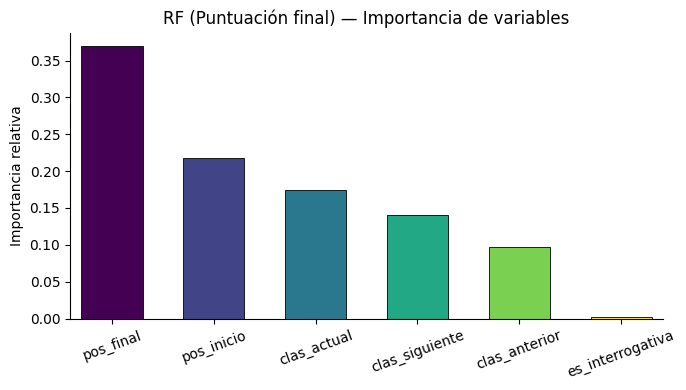

In [21]:
# TABLAS: SOLO F1 POR CLASE 

def tabla_f1_por_clase(y_true, y_pred, class_names, nombre_tarea):
    """
    Construye una tabla con solo F1 por clase.
    """
    report = classification_report(y_true, y_pred, output_dict=True)

    filas = []
    for i, clase in enumerate(class_names):
        info = report[str(i)]
        filas.append({
            "Clase": clase,
            "F1": round(info["f1-score"], 3),
        })

    df = pd.DataFrame(filas)
    print(f"\n=== {nombre_tarea} — F1 por clase ===")
    display(df)
    return df

# 1) Puntuación inicial
tabla_ini = tabla_f1_por_clase(
    y_val_inicial_palabra,
    y_pred_val_inicial,
    class_names=["sin signo inicial", "¿"],
    nombre_tarea="Puntuación inicial (RF)"
)

# 2) Puntuación final
tabla_fin = tabla_f1_por_clase(
    y_val_final_palabra,
    y_pred_val_final,
    class_names=["sin signo", "coma", "punto", "?"],
    nombre_tarea="Puntuación final (RF)"
)

# 3) Capitalización
tabla_cap = tabla_f1_por_clase(
    y_val_capit_palabra,
    y_pred_val_capit,
    class_names=["minúscula", "MayusInicial", "Mixta", "MAYÚSCULAS"],
    nombre_tarea="Capitalización (RF)"
)

# F1 macro global por tarea (para comparar RF vs RNN vs BiRNN después)
f1_ini = f1_score(y_val_inicial_palabra, y_pred_val_inicial, average="macro")
f1_fin = f1_score(y_val_final_palabra,   y_pred_val_final,   average="macro")
f1_cap = f1_score(y_val_capit_palabra,   y_pred_val_capit,   average="macro")

print("\n=== F1 macro por tarea (RF) ===")
print("Punt. inicial:", f1_ini)
print("Punt. final:  ", f1_fin)
print("Capitalización:", f1_cap)

# GRÁFICO: IMPORTANCIA DE VARIABLES (RF PUNT. FINAL)

importances = rf_final.feature_importances_
feature_names = X_train_RF.columns

# Ordenar de mayor a menor importancia
idx_orden = np.argsort(importances)[::-1]
importances_ordenadas = importances[idx_orden]
nombres_ordenados = [feature_names[i] for i in idx_orden]

plt.figure(figsize=(7, 4))
x = np.arange(len(importances_ordenadas))

width = 0.6

cmap_imp = plt.colormaps.get_cmap("viridis")
colores_imp = [
    cmap_imp(i / (len(importances_ordenadas) - 1 or 1))
    for i in range(len(importances_ordenadas))
]

plt.bar(
    x,
    importances_ordenadas,
    width=width,
    color=colores_imp,
    edgecolor="black",
    linewidth=0.6
)

plt.xticks(x, nombres_ordenados, rotation=20, ha="center")
plt.ylabel("Importancia relativa")
plt.title("RF (Puntuación final) — Importancia de variables")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.margins(x=0.02)
plt.tight_layout()
plt.show()

## Conclusiones del Modelo Random Forest

**1. Puntuación inicial (¿)**  

El modelo logra detectar el signo de apertura **¿** de forma razonable. Esto tiene sentido por la feature "interrogativa" que seguramente le 'facilita' la tarea al RF. 
Los falsos positivos son muy pocos y los falsos negativos son moderados.

**2. Puntuación final (, . ?)**  

- El modelo predice **“sin signo final”** para casi todo.
- Las **comas** se detectan muy poco.
- Los **puntos** se confunden con “sin signo”.
- Los **signos de pregunta (?)** prácticamente no se predicen.
- Esto pasa porque decidir la puntuación final de una palabra requiere **contexto amplio**:

**3. Capitalización**  

El modelo maneja bien la clase dominante (“minúscula”), pero falla en:

- Mayúscula inicial → se confunde con minúscula.
- Capitalización mixta (iPhone, McDonalds) → casi nunca detectada.
- Palabras en MAYÚSCULAS (siglas como UBA, NASA) → prácticamente no detectadas.

Estas clases requieren semántica, conocimiento del tipo de palabra y frecuencia en textos, lo cual no está presente en las features actuales.

**Posibles mejoras del modelo :**

- Podríamos agregar más features (no se nos ocurrieron otros que creamos útiles para el RF además de los propuestos).


---
## Embeddings

En el caso de las RNN, lo que hacemos es utilizar sus embedding como features para lo que recurrimos a BERT.

In [22]:
map_ini = {"":0, "¿":1}
map_fin = {"":0, ",":1, ".":2, "?":3}

model = BertModel.from_pretrained("bert-base-multilingual-cased")
model.eval()
embeddings_matrix = model.get_input_embeddings().weight.detach().numpy()

cant_clases_punt_inicial = 2
cant_clases_punt_final = 4
cant_clases_capitalizacion = 4

def guardar_embeddings_pickle(df_tokens, embeddings_matrix, filename):
    """
    Guarda embeddings en formato pickle porque es menos pesado que csv
    """
    embeddings_dict = {}

    for instancia_id in df_tokens['instancia_id'].unique():
        df_inst = df_tokens[df_tokens['instancia_id'] == instancia_id].reset_index(drop=True)

        # Extraemos información
        token_ids = df_inst['token_id'].values
        embeddings = embeddings_matrix[token_ids]

        embeddings_dict[instancia_id] = {
            'embeddings': torch.FloatTensor(embeddings),
            'length': len(embeddings)
        }

    with open(filename, 'wb') as f:
        pickle.dump(embeddings_dict, f)


def cargamos_embeddings_pickle(filename):
    """
    Carga embeddings desde pickle
    Devuelve diccionario con embeddings
    """
    with open(filename, 'rb') as f:
        embeddings_dict = pickle.load(f)

    return embeddings_dict


def preparamos_etiquetas_dict(df_tokens):
    """
    Crea diccionario con las etiquetas de predicción desde df_tokens
    """
    etiquetas_dict = {}

    for instancia_id in df_tokens['instancia_id'].unique():
        df_inst = df_tokens[df_tokens['instancia_id'] == instancia_id].reset_index(drop=True)

        # Mapeamos etiquetas a números
        punt_ini = [map_ini[label] for label in df_inst['punt_inicial'].tolist()]
        punt_fin = [map_fin[label] for label in df_inst['punt_final'].tolist()]
        cap = df_inst['capitalización'].astype(int).tolist()

        etiquetas_dict[instancia_id] = {
            'punt_inicial': torch.LongTensor(punt_ini),
            'punt_final': torch.LongTensor(punt_fin),
            'capitalizacion': torch.LongTensor(cap)
        }

    return etiquetas_dict


def collate_fn_separado(batch, embeddings_dicc, etiquetas_dict):
    """
    Collate function que usa embeddings y etiquetas pre-computados

    Args:
        batch: Lista de instancia_ids
        embeddings_dicc: Diccionario con embeddings por instancia
        etiquetas_dict: Diccionario con etiquetas por instancia

    Returns:
        Diccionario con tensores paddeados y máscaras de atención
    """
    # Obtenemos datos
    items_emb = [embeddings_dicc[inst_id] for inst_id in batch]
    items_label = [etiquetas_dict[inst_id] for inst_id in batch]

    # Longitudes
    lengths = torch.LongTensor([item['length'] for item in items_emb])
    max_len = lengths.max().item()
    batch_size = len(items_emb)

    # Preparamos tensores con padding
    embeddings_padded = torch.zeros(batch_size, max_len, 768)
    punt_ini_padded = torch.full((batch_size, max_len), -100, dtype=torch.long)  # -100 es el ignore_index por defecto
    punt_fin_padded = torch.full((batch_size, max_len), -100, dtype=torch.long)
    cap_padded = torch.full((batch_size, max_len), -100, dtype=torch.long)

    for i in range(batch_size):
        seq_len = items_emb[i]['length']
        embeddings_padded[i, :seq_len] = items_emb[i]['embeddings']
        punt_ini_padded[i, :seq_len] = items_label[i]['punt_inicial']
        punt_fin_padded[i, :seq_len] = items_label[i]['punt_final']
        cap_padded[i, :seq_len] = items_label[i]['capitalizacion']

    return {
        'embeddings': embeddings_padded,
        'punt_inicial': punt_ini_padded,
        'punt_final': punt_fin_padded,
        'capitalizacion': cap_padded,
        'lengths': lengths
    }


In [23]:
# Guardar embeddings
guardar_embeddings_pickle(df_train, embeddings_matrix, 'embeddings_train.pkl')
guardar_embeddings_pickle(df_val, embeddings_matrix, 'embeddings_val.pkl')

In [24]:
# cargamos los embeddings por isntancia
# preparamos dos collate_fn uno para train y otro para validacion
# asi pytorch puede usar estos directamente para alimentar la red

embeddings_train = cargamos_embeddings_pickle('embeddings_train.pkl')
embeddings_val = cargamos_embeddings_pickle('embeddings_val.pkl')
y_train = preparamos_etiquetas_dict(df_train)
y_val = preparamos_etiquetas_dict(df_val)

train_collate = partial(collate_fn_separado,
                        embeddings_dicc=embeddings_train,
                        etiquetas_dict=y_train)

val_collate = partial(collate_fn_separado,
                      embeddings_dicc=embeddings_val,
                      etiquetas_dict=y_val)

In [25]:
batch_size = 32

train_loader = DataLoader(
    list(embeddings_train.keys()),
    batch_size=batch_size,
    shuffle=True,
    collate_fn=train_collate
)

val_loader = DataLoader(
    list(embeddings_val.keys()),
    batch_size=batch_size,
    shuffle=False,
    collate_fn=val_collate
)

In [26]:
# GPU para entrenar mas rapido:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

---
## Modelo RNN unidireccional

Arrancamos entrenanado una RNN unidireccional con 2 capas ocultas de tamaño 250 y 10 épocas y activaciones lineales. Fuimos haciendo pruebas con menos datos, tamaño más pequeño de las capas ocultas y cantidad de épocas, pero este fue el que nos anduvo mejor en cuanto al F1 para cada clase de cada predicción.

Llegamos a probar hasta 100 épocas y nos dimos cuenta que a las 10 épocas (aprox) la loss de validación empezaba aumentar, mientras que la de entrenamiento era casi cero. Por eso, decidimos dejar la cantidad de épocas en 10.

Además nos dimos cuenta que estaba prediciendo mejor las clases "básicas" (sin puntuación/capitalización), por lo que decidimos ponerle mayor penalización a la loss de las otras clases para lograr una mejor detección de las mismas.

In [27]:
class PuntuacionRNN(nn.Module):
    """
    RNN para clasificación secuencia-a-secuencia.
    Predice 3 tareas simultáneas: puntuación inicial, final y capitalización.
    """

    def __init__(self, input_size=768, hidden_size=250, num_layers=2,
                 cant_clases_punt_inicial=2, cant_clases_punt_final=4,
                 cant_clases_capitalizacion=4,
                 bidirectional=False):
        super(PuntuacionRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            nonlinearity='tanh'
        )

        directions = 2 if bidirectional else 1
        rnn_output_size = hidden_size * directions

        self.fc_punt_ini = nn.Linear(rnn_output_size, cant_clases_punt_inicial)
        self.fc_punt_fin = nn.Linear(rnn_output_size, cant_clases_punt_final)
        self.fc_cap = nn.Linear(rnn_output_size, cant_clases_capitalizacion)

    def forward(self, embeddings, lengths):
        """
        Args:
            embeddings: (batch_size, max_seq_len, 768)
            lengths: (batch_size,) longitudes reales de cada secuencia
        """
        # ignoramos padding con pack_padded_sequence, el cual agregamos porque todas las instancias tienen diferente largo
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embeddings,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, hidden = self.rnn(packed_input)

        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)

        logits_punt_ini = self.fc_punt_ini(output)  
        logits_punt_fin = self.fc_punt_fin(output)  
        logits_cap      = self.fc_cap(output)      

        return logits_punt_ini, logits_punt_fin, logits_cap

# Puntuacion inicial:
weights_ini = torch.tensor([1.0, 20.0], device=device)  

# Puntuacion final: 
weights_fin = torch.tensor([1.0, 10.0, 10.0, 15.0], device=device)

# Capitalización: 
weights_cap = torch.tensor([1.0, 5.0, 8.0, 8.0], device=device)

criterion_ini = nn.CrossEntropyLoss(weight=weights_ini)
criterion_fin = nn.CrossEntropyLoss(weight=weights_fin)
criterion_cap = nn.CrossEntropyLoss(weight=weights_cap)


def train_epoch(model, dataloader, optimizer, criterions, device):
    """
    Entrena el modelo por una época.
    Args:
        model: modelo a entrenar
        dataloader: DataLoader con datos de entrenamiento
        optimizer: optimizador
        criterions: dict con {'ini': criterion_ini, 'fin': criterion_fin, 'cap': criterion_cap}
        device: dispositivo (CPU/GPU)
    Returns:
        Pérdida promedio en la época
    """
    model.train()
    total_loss = 0

    for batch in dataloader:
        embeddings = batch['embeddings'].to(device) #me aseguro de correr x gpu
        lengths = batch['lengths']
        
        # Pasada Forward
        optimizer.zero_grad()
        logits_ini, logits_fin, logits_cap = model(embeddings, lengths)
        
        # Preparamos targets (flatten una sola vez)
        targets_ini = batch['punt_inicial'].to(device).view(-1) #tambien chequeo de correr x gpu
        targets_fin = batch['punt_final'].to(device).view(-1)
        targets_cap = batch['capitalizacion'].to(device).view(-1)
        
        # Máscara para ignorar padding
        mask = targets_ini != -100
        
        # Perdida (aplicando máscara)
        loss = (
            criterions['ini'](logits_ini.view(-1, 2)[mask], targets_ini[mask]) +
            criterions['fin'](logits_fin.view(-1, 4)[mask], targets_fin[mask]) +
            criterions['cap'](logits_cap.view(-1, 4)[mask], targets_cap[mask])
        )
        
        # Pasada Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluacion(model, dataloader, criterions, device):
    """
    Evalúa el modelo en el conjunto de validación.
    Args:
        model: modelo a evaluar
        dataloader: DataLoader con datos de validación
        criterions: dict con {'ini': criterion_ini, 'fin': criterion_fin, 'cap': criterion_cap}
        device: dispositivo (CPU/GPU)
    Returns:
        avg_loss: pérdida promedio en validación
    """
    model.eval()
    total_loss = 0
    
    # Diccionario para almacenar predicciones y targets
    all_preds = {'ini': [], 'fin': [], 'cap': []}
    all_targets = {'ini': [], 'fin': [], 'cap': []}

    with torch.no_grad():
        for batch in dataloader:
            embeddings = batch['embeddings'].to(device)
            lengths = batch['lengths']
            
            # Forward
            logits_ini, logits_fin, logits_cap = model(embeddings, lengths)
            
            # Preparamos targets (flatten una sola vez, para que lo lea bien)
            targets_ini = batch['punt_inicial'].to(device).view(-1) #chqe a gpu
            targets_fin = batch['punt_final'].to(device).view(-1)
            targets_cap = batch['capitalizacion'].to(device).view(-1)
            
            # Máscara para ignorar padding
            mask = targets_ini != -100
            
            # Pérddida (aplicando máscara)
            loss = (
                criterions['ini'](logits_ini.view(-1, 2)[mask], targets_ini[mask]) +
                criterions['fin'](logits_fin.view(-1, 4)[mask], targets_fin[mask]) +
                criterions['cap'](logits_cap.view(-1, 4)[mask], targets_cap[mask])
            )
            total_loss += loss.item()
            
            # Predicciones (argmax sobre logits enmascarados)
            preds_ini = torch.argmax(logits_ini.view(-1, 2)[mask], dim=1)
            preds_fin = torch.argmax(logits_fin.view(-1, 4)[mask], dim=1)
            preds_cap = torch.argmax(logits_cap.view(-1, 4)[mask], dim=1)
            
            # Guardamos predicciones y targets
            all_preds['ini'].extend(preds_ini.cpu().numpy())
            all_targets['ini'].extend(targets_ini[mask].cpu().numpy())
            
            all_preds['fin'].extend(preds_fin.cpu().numpy())
            all_targets['fin'].extend(targets_fin[mask].cpu().numpy())
            
            all_preds['cap'].extend(preds_cap.cpu().numpy())
            all_targets['cap'].extend(targets_cap[mask].cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    
    return avg_loss, (
        all_preds['ini'], all_targets['ini'],
        all_preds['fin'], all_targets['fin'],
        all_preds['cap'], all_targets['cap']
    )


print("\n" + "="*60)
print("INICIANDO ENTRENAMIENTO (Modelo RNN con pesos de clase)")
print("="*60)

model = PuntuacionRNN(
    input_size=768,
    hidden_size=250,
    num_layers=2,
    cant_clases_punt_inicial=2,
    cant_clases_punt_final=4,
    cant_clases_capitalizacion=4,
    bidirectional=False
).to(device)

print(f"\nModelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_val_loss = float('inf')
criterions = {
    'ini': criterion_ini,
    'fin': criterion_fin,
    'cap': criterion_cap
}

for epoch in range(num_epochs):
    print(f"\nÉpoca {epoch+1}/{num_epochs}")

    train_loss = train_epoch(
        model, train_loader, optimizer,
        criterions, device
    )
    print(f"  Loss entrenamiento: {train_loss:.4f}")

    val_loss, predictions = evaluacion(
        model, val_loader,
        criterions, device
    )
    print(f"  Loss validación: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

print("\n" + "="*60)
print("EVALUACIÓN FINAL")
print("="*60)

model.load_state_dict(torch.load('best_model.pth'))

_, (preds_punt_ini, targets_punt_ini,
    preds_punt_fin, targets_punt_fin,
    preds_cap, targets_cap) = evaluacion(
    model, val_loader,
    criterions, device
)


# Metricas (ignorando padding)
def filtrar_padding(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != -100
    return y_true[mask], y_pred[mask]

# Puntuación inicial:
t_ini_true, t_ini_pred = filtrar_padding(targets_punt_ini, preds_punt_ini)
print("\n--- PUNTUACIÓN INICIAL ---")
print(classification_report(
    t_ini_true, t_ini_pred,
    target_names=["sin signo", "¿"]
))

# Puntuación final:
t_fin_true, t_fin_pred = filtrar_padding(targets_punt_fin, preds_punt_fin)
print("\n--- PUNTUACIÓN FINAL ---")
print(classification_report(
    t_fin_true, t_fin_pred,
    target_names=["sin signo", "coma", "punto", "?"]
))

# Capitalización: 
t_cap_true, t_cap_pred = filtrar_padding(targets_cap, preds_cap)
print("\n--- CAPITALIZACIÓN ---")
print(classification_report(
    t_cap_true, t_cap_pred,
    target_names=["minúscula", "mayúsc. inicial", "mixta", "todo mayúsc."]
))


INICIANDO ENTRENAMIENTO (Modelo RNN con pesos de clase)

Modelo creado con 383010 parámetros

Época 1/10
  Loss entrenamiento: 1.6414
  Loss validación: 1.2516

Época 2/10
  Loss entrenamiento: 1.3633
  Loss validación: 1.2532

Época 3/10
  Loss entrenamiento: 1.3008
  Loss validación: 1.2178

Época 4/10
  Loss entrenamiento: 1.2599
  Loss validación: 1.1494

Época 5/10
  Loss entrenamiento: 1.2172
  Loss validación: 1.1399

Época 6/10
  Loss entrenamiento: 1.1895
  Loss validación: 1.1579

Época 7/10
  Loss entrenamiento: 1.1573
  Loss validación: 1.1642

Época 8/10
  Loss entrenamiento: 1.1301
  Loss validación: 1.1488

Época 9/10
  Loss entrenamiento: 1.1027
  Loss validación: 1.1795

Época 10/10
  Loss entrenamiento: 1.0755
  Loss validación: 1.2154

EVALUACIÓN FINAL

--- PUNTUACIÓN INICIAL ---
              precision    recall  f1-score   support

   sin signo       1.00      0.99      0.99     62126
           ¿       0.02      0.91      0.04        22

    accuracy             

**Unidireccional con LSTM**

Decidimos además probar usando LSTM (dejando el resto como estaba) debido a que tienen mejor comportamiento a "largo plazo" y para un problema que requiere del contexto tanto como este (puntualizacion y capitalizacion) tiene más sentido aprovechar bien el uso de la MEMORIA. 

In [28]:
class PuntuacionRNN_LSTM(nn.Module):
    """
    RNN para clasificación secuencia-a-secuencia.
    Predice 3 tareas simultáneas: puntuación inicial, final y capitalización.
    """

    def __init__(self, input_size=768, hidden_size=250, num_layers=2,
                 cant_clases_punt_inicial=2, cant_clases_punt_final=4,
                 cant_clases_capitalizacion=4,
                 bidirectional=False):
        super(PuntuacionRNN_LSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        directions = 2 if bidirectional else 1
        lstm_output_size = hidden_size * directions

        self.fc_punt_ini = nn.Linear(lstm_output_size, cant_clases_punt_inicial)
        self.fc_punt_fin = nn.Linear(lstm_output_size, cant_clases_punt_final)
        self.fc_cap = nn.Linear(lstm_output_size, cant_clases_capitalizacion)

    def forward(self, embeddings, lengths):
        """
        Args:
            embeddings: (batch_size, max_seq_len, 768)
            lengths: (batch_size,) longitudes reales de cada secuencia
        """
        # ignoramos padding con pack_padded_sequence, el cual agregamos porque todas las instancias tienen diferente largo
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embeddings,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (hidden, cell) = self.lstm(packed_input)

        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)

        logits_punt_ini = self.fc_punt_ini(output)  
        logits_punt_fin = self.fc_punt_fin(output)  
        logits_cap      = self.fc_cap(output)      

        return logits_punt_ini, logits_punt_fin, logits_cap

# Puntuacion inicial:
weights_ini = torch.tensor([1.0, 20.0], device=device)  

# Puntuacion final: 
weights_fin = torch.tensor([1.0, 10.0, 10.0, 15.0], device=device)

# Capitalización: 
weights_cap = torch.tensor([1.0, 5.0, 8.0, 8.0], device=device)

criterion_ini = nn.CrossEntropyLoss(weight=weights_ini)
criterion_fin = nn.CrossEntropyLoss(weight=weights_fin)
criterion_cap = nn.CrossEntropyLoss(weight=weights_cap)


def train_epoch_LSTM(model, dataloader, optimizer, criterions, device):
    """
    Entrena el modelo por una época.
    Args:
        model: modelo a entrenar
        dataloader: DataLoader con datos de entrenamiento
        optimizer: optimizador
        criterions: dict con {'ini': criterion_ini, 'fin': criterion_fin, 'cap': criterion_cap}
        device: dispositivo (CPU/GPU)
    Returns:
        Pérdida promedio en la época
    """
    model.train()
    total_loss = 0

    for batch in dataloader:
        embeddings = batch['embeddings'].to(device) #me aseguro de correr x gpu
        lengths = batch['lengths']
        
        # Pasada Forward
        optimizer.zero_grad()
        logits_ini, logits_fin, logits_cap = model(embeddings, lengths)
        
        # Preparamos targets (flatten una sola vez)
        targets_ini = batch['punt_inicial'].to(device).view(-1) #tambien chequeo de correr x gpu
        targets_fin = batch['punt_final'].to(device).view(-1)
        targets_cap = batch['capitalizacion'].to(device).view(-1)
        
        # Máscara para ignorar padding
        mask = targets_ini != -100
        
        # perd9da (aplicando máscara)
        loss = (
            criterions['ini'](logits_ini.view(-1, 2)[mask], targets_ini[mask]) +
            criterions['fin'](logits_fin.view(-1, 4)[mask], targets_fin[mask]) +
            criterions['cap'](logits_cap.view(-1, 4)[mask], targets_cap[mask])
        )
        
        # Pasada Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluacion_LSTM(model, dataloader, criterions, device):
    """
    Evalúa el modelo en el conjunto de validación.
    Args:
        model: modelo a evaluar
        dataloader: DataLoader con datos de validación
        criterions: dict con {'ini': criterion_ini, 'fin': criterion_fin, 'cap': criterion_cap}
        device: dispositivo (CPU/GPU)
    Returns:
        avg_loss: pérdida promedio en validación
    """
    model.eval()
    total_loss = 0
    
    # Diccionario para almacenar predicciones y targets
    all_preds = {'ini': [], 'fin': [], 'cap': []}
    all_targets = {'ini': [], 'fin': [], 'cap': []}

    with torch.no_grad():
        for batch in dataloader:
            embeddings = batch['embeddings'].to(device)
            lengths = batch['lengths']
            
            # Forward
            logits_ini, logits_fin, logits_cap = model(embeddings, lengths)
            
            # Preparamos targets (flatten una sola vez, para que lo lea bien)
            targets_ini = batch['punt_inicial'].to(device).view(-1) #chqe a gpu
            targets_fin = batch['punt_final'].to(device).view(-1)
            targets_cap = batch['capitalizacion'].to(device).view(-1)
            
            # Máscara para ignorar padding
            mask = targets_ini != -100
            
            # Pérddida (aplicando máscara)
            loss = (
                criterions['ini'](logits_ini.view(-1, 2)[mask], targets_ini[mask]) +
                criterions['fin'](logits_fin.view(-1, 4)[mask], targets_fin[mask]) +
                criterions['cap'](logits_cap.view(-1, 4)[mask], targets_cap[mask])
            )
            total_loss += loss.item()
            
            # Predicciones (argmax sobre logits enmascarados)
            preds_ini = torch.argmax(logits_ini.view(-1, 2)[mask], dim=1)
            preds_fin = torch.argmax(logits_fin.view(-1, 4)[mask], dim=1)
            preds_cap = torch.argmax(logits_cap.view(-1, 4)[mask], dim=1)
            
            # Guardamos predicciones y targets
            all_preds['ini'].extend(preds_ini.cpu().numpy())
            all_targets['ini'].extend(targets_ini[mask].cpu().numpy())
            
            all_preds['fin'].extend(preds_fin.cpu().numpy())
            all_targets['fin'].extend(targets_fin[mask].cpu().numpy())
            
            all_preds['cap'].extend(preds_cap.cpu().numpy())
            all_targets['cap'].extend(targets_cap[mask].cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    
    return avg_loss, (
        all_preds['ini'], all_targets['ini'],
        all_preds['fin'], all_targets['fin'],
        all_preds['cap'], all_targets['cap']
    )


print("\n" + "="*60)
print("INICIANDO ENTRENAMIENTO (Modelo RNN con pesos de clase)")
print("="*60)

model = PuntuacionRNN_LSTM(
    input_size=768,
    hidden_size=250,
    num_layers=2,
    cant_clases_punt_inicial=2,
    cant_clases_punt_final=4,
    cant_clases_capitalizacion=4,
    bidirectional=False
).to(device)

print(f"\nModelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_val_loss = float('inf')
criterions = {
    'ini': criterion_ini,
    'fin': criterion_fin,
    'cap': criterion_cap
}

for epoch in range(num_epochs):
    print(f"\nÉpoca {epoch+1}/{num_epochs}")

    train_loss = train_epoch_LSTM(
        model, train_loader, optimizer,
        criterions, device
    )
    print(f"  Loss entrenamiento: {train_loss:.4f}")

    val_loss, predictions = evaluacion_LSTM(
        model, val_loader,
        criterions, device
    )
    print(f"  Loss validación: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

print("\n" + "="*60)
print("EVALUACIÓN FINAL")
print("="*60)

model.load_state_dict(torch.load('best_model.pth'))

_, (preds_punt_ini, targets_punt_ini,
    preds_punt_fin, targets_punt_fin,
    preds_cap, targets_cap) = evaluacion_LSTM(
    model, val_loader,
    criterions, device
)


# Métricas (ignorando padding)

def filtrar_padding(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != -100
    return y_true[mask], y_pred[mask]

# Puntuación inicial:
t_ini_true, t_ini_pred = filtrar_padding(targets_punt_ini, preds_punt_ini)
print("\n--- PUNTUACIÓN INICIAL ---")
print(classification_report(
    t_ini_true, t_ini_pred,
    target_names=["sin signo", "¿"]
))

# Puntuación final:
t_fin_true, t_fin_pred = filtrar_padding(targets_punt_fin, preds_punt_fin)
print("\n--- PUNTUACIÓN FINAL ---")
print(classification_report(
    t_fin_true, t_fin_pred,
    target_names=["sin signo", "coma", "punto", "?"]
))

# Capitalización: 
t_cap_true, t_cap_pred = filtrar_padding(targets_cap, preds_cap)
print("\n--- CAPITALIZACIÓN ---")
print(classification_report(
    t_cap_true, t_cap_pred,
    target_names=["minúscula", "mayúsc. inicial", "mixta", "todo mayúsc."]
))


INICIANDO ENTRENAMIENTO (Modelo RNN con pesos de clase)

Modelo creado con 1524510 parámetros

Época 1/10
  Loss entrenamiento: 1.8285
  Loss validación: 1.3687

Época 2/10
  Loss entrenamiento: 1.3569
  Loss validación: 1.1750

Época 3/10
  Loss entrenamiento: 1.2553
  Loss validación: 1.1274

Época 4/10
  Loss entrenamiento: 1.2037
  Loss validación: 1.0816

Época 5/10
  Loss entrenamiento: 1.1571
  Loss validación: 1.0981

Época 6/10
  Loss entrenamiento: 1.1122
  Loss validación: 1.0884

Época 7/10
  Loss entrenamiento: 1.0628
  Loss validación: 1.0805

Época 8/10
  Loss entrenamiento: 1.0148
  Loss validación: 1.0806

Época 9/10
  Loss entrenamiento: 0.9650
  Loss validación: 1.0811

Época 10/10
  Loss entrenamiento: 0.9084
  Loss validación: 1.0625

EVALUACIÓN FINAL

--- PUNTUACIÓN INICIAL ---
              precision    recall  f1-score   support

   sin signo       1.00      1.00      1.00     62126
           ¿       0.06      0.91      0.11        22

    accuracy            

---
## Modelo de RNN bidireccional (LSTM)

Para la RNN bidireccional decidimos directamente usar LSTM porque ya habíamos comprobado que funcionaba muchísimo mejor para este problema en la unidireccional. No cambiamos los tamaños de las hidden ni la cantidad de capas ocultas para comparar performance en las mismas circunstancias.

Probamos (para todas las redes) con distintos tamaños de hidden. Pero nos parecía que probar con demasiadas capas ocultas iba a tardar demasiado y no iba  a mejorar demasiado. 

In [29]:
class PuntuacionRNN_Bidireccional(nn.Module):
    """
    RNN Bidireccional para clasificación secuencia-a-secuencia.
    Predice 3 tareas simultáneas: puntuación inicial, final y capitalización.
    """

    def __init__(self, input_size=768, hidden_size=250, num_layers=2,
                 cant_clases_punt_inicial=2, cant_clases_punt_final=4, 
                 cant_clases_capitalizacion=4):
        super(PuntuacionRNN_Bidireccional, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True  
        )

        # *2 porque es bidireccional (procesa hacia adelante y hacia atrás)
        lstm_output_size = hidden_size * 2  

        # Capas de salida para cada tarea
        self.fc_punt_ini = nn.Linear(lstm_output_size, cant_clases_punt_inicial)
        self.fc_punt_fin = nn.Linear(lstm_output_size, cant_clases_punt_final)
        self.fc_cap = nn.Linear(lstm_output_size, cant_clases_capitalizacion)

    def forward(self, embeddings, lengths):
        """
        Args:
            embeddings: (batch_size, max_seq_len, 768)
            lengths: (batch_size,) longitudes reales de cada secuencia
        """
        # Ignoramos padding con pack_padded_sequence
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embeddings,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (hidden, cell) = self.lstm(packed_input)
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)

        # Predicciones para cada tarea
        logits_punt_ini = self.fc_punt_ini(output)
        logits_punt_fin = self.fc_punt_fin(output)
        logits_cap = self.fc_cap(output)

        return logits_punt_ini, logits_punt_fin, logits_cap


#aun buscamos penalizar mas los errores en las clases menos frecuentes

weights_ini = torch.tensor([1.0, 20.0], device=device)  
weights_fin = torch.tensor([1.0, 10.0, 10.0, 15.0], device=device)
weights_cap = torch.tensor([1.0, 5.0, 8.0, 8.0], device=device)

criterions = {
    'ini': nn.CrossEntropyLoss(weight=weights_ini),
    'fin': nn.CrossEntropyLoss(weight=weights_fin),
    'cap': nn.CrossEntropyLoss(weight=weights_cap)
}


def train_epoch_bidireccional(model, dataloader, optimizer, criterions, device):
    """
    Entrena el modelo por una época.
    Args:
        model: modelo a entrenar
        dataloader: DataLoader con datos de entrenamiento
        optimizer: optimizador
        criterions: dict con {'ini': criterion_ini, 'fin': criterion_fin, 'cap': criterion_cap}
        device: dispositivo (CPU/GPU)
    Returns:
        Pérdida promedio en la época
    """
    model.train()
    total_loss = 0

    for batch in dataloader:
        embeddings = batch['embeddings'].to(device)  # A GPU
        lengths = batch['lengths']
        
        # Pasada Forward
        optimizer.zero_grad()
        logits_ini, logits_fin, logits_cap = model(embeddings, lengths)
        
        # Preparamos targets (flatten una sola vez)
        targets_ini = batch['punt_inicial'].to(device).view(-1)  # A GPU
        targets_fin = batch['punt_final'].to(device).view(-1)
        targets_cap = batch['capitalizacion'].to(device).view(-1)
        
        # Máscara para ignorar padding (-100)
        mask = targets_ini != -100
        
        # perdida (aplicando máscara)
        loss = (
            criterions['ini'](logits_ini.view(-1, 2)[mask], targets_ini[mask]) +
            criterions['fin'](logits_fin.view(-1, 4)[mask], targets_fin[mask]) +
            criterions['cap'](logits_cap.view(-1, 4)[mask], targets_cap[mask])
        )
        
        # Pasada Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluacion_bidireccional(model, dataloader, criterions, device):
    """
    Evalúa el modelo en el conjunto de validación.
    Args:
        model: modelo a evaluar
        dataloader: DataLoader con datos de validación
        criterions: dict con {'ini': criterion_ini, 'fin': criterion_fin, 'cap': criterion_cap}
        device: dispositivo (CPU/GPU)
    Returns:
        avg_loss: pérdida promedio en validación
        predictions: tupla con predicciones y targets para cada tarea
    """
    model.eval()
    total_loss = 0
    
    # Diccionario para almacenar predicciones y targets
    all_preds = {'ini': [], 'fin': [], 'cap': []}
    all_targets = {'ini': [], 'fin': [], 'cap': []}

    with torch.no_grad():
        for batch in dataloader:
            embeddings = batch['embeddings'].to(device)
            lengths = batch['lengths']
            
            # Forward
            logits_ini, logits_fin, logits_cap = model(embeddings, lengths)
            
            # Preparamos targets (flatten una sola vez)
            targets_ini = batch['punt_inicial'].to(device).view(-1)
            targets_fin = batch['punt_final'].to(device).view(-1)
            targets_cap = batch['capitalizacion'].to(device).view(-1)
            
            # Máscara para ignorar padding
            mask = targets_ini != -100
            
            # Pérdida (aplicando máscara)
            loss = (
                criterions['ini'](logits_ini.view(-1, 2)[mask], targets_ini[mask]) +
                criterions['fin'](logits_fin.view(-1, 4)[mask], targets_fin[mask]) +
                criterions['cap'](logits_cap.view(-1, 4)[mask], targets_cap[mask])
            )
            total_loss += loss.item()
            
            # Predicciones (argmax sobre logits enmascarados)
            preds_ini = torch.argmax(logits_ini.view(-1, 2)[mask], dim=1)
            preds_fin = torch.argmax(logits_fin.view(-1, 4)[mask], dim=1)
            preds_cap = torch.argmax(logits_cap.view(-1, 4)[mask], dim=1)
            
            # Guardamos predicciones y targets
            all_preds['ini'].extend(preds_ini.cpu().numpy())
            all_targets['ini'].extend(targets_ini[mask].cpu().numpy())
            
            all_preds['fin'].extend(preds_fin.cpu().numpy())
            all_targets['fin'].extend(targets_fin[mask].cpu().numpy())
            
            all_preds['cap'].extend(preds_cap.cpu().numpy())
            all_targets['cap'].extend(targets_cap[mask].cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    
    return avg_loss, (
        all_preds['ini'], all_targets['ini'],
        all_preds['fin'], all_targets['fin'],
        all_preds['cap'], all_targets['cap']
    )


print("\n" + "="*60)
print("INICIANDO ENTRENAMIENTO (Modelo Bi-LSTM con pesos de clase)")
print("="*60)

model = PuntuacionRNN_Bidireccional(
    input_size=768,
    hidden_size=250, 
    num_layers=2,
    cant_clases_punt_inicial=2,
    cant_clases_punt_final=4,
    cant_clases_capitalizacion=4
).to(device)

print(f"\nModelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f"\nÉpoca {epoch+1}/{num_epochs}")

    train_loss = train_epoch_bidireccional(model, train_loader, optimizer, criterions, device)
    print(f"  Loss entrenamiento: {train_loss:.4f}")

    val_loss, predictions = evaluacion_bidireccional(model, val_loader, criterions, device)
    print(f"  Loss validación: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_bilstm.pth')


print("\n" + "="*60)
print("EVALUACIÓN FINAL")
print("="*60)

model.load_state_dict(torch.load('best_model_bilstm.pth'))

_, (preds_punt_ini, targets_punt_ini,
    preds_punt_fin, targets_punt_fin,
    preds_cap, targets_cap) = evaluacion_bidireccional(model, val_loader, criterions, device)


# Métricas (ignorando padding)

def filtrar_padding(y_true, y_pred):
    """Filtra las etiquetas de padding (-100) antes de calcular métricas"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != -100
    return y_true[mask], y_pred[mask]

# Puntuación iniciak:
t_ini_true, t_ini_pred = filtrar_padding(targets_punt_ini, preds_punt_ini)
print("\n--- PUNTUACIÓN INICIAL ---")
print(classification_report(
    t_ini_true, t_ini_pred,
    target_names=["sin signo", "¿"]
))

# Puntuación final:
t_fin_true, t_fin_pred = filtrar_padding(targets_punt_fin, preds_punt_fin)
print("\n--- PUNTUACIÓN FINAL ---")
print(classification_report(
    t_fin_true, t_fin_pred,
    target_names=["sin signo", "coma", "punto", "?"]
))

# Capitalizacióm:
t_cap_true, t_cap_pred = filtrar_padding(targets_cap, preds_cap)
print("\n--- CAPITALIZACIÓN ---")
print(classification_report(
    t_cap_true, t_cap_pred,
    target_names=["minúscula", "mayúsc. inicial", "mixta", "todo mayúsc."]
))



INICIANDO ENTRENAMIENTO (Modelo Bi-LSTM con pesos de clase)

Modelo creado con 3549010 parámetros

Época 1/10
  Loss entrenamiento: 1.5089
  Loss validación: 0.9635

Época 2/10
  Loss entrenamiento: 1.0037
  Loss validación: 0.7763

Época 3/10
  Loss entrenamiento: 0.8687
  Loss validación: 0.7482

Época 4/10
  Loss entrenamiento: 0.7962
  Loss validación: 0.7074

Época 5/10
  Loss entrenamiento: 0.7230
  Loss validación: 0.6724

Época 6/10
  Loss entrenamiento: 0.6560
  Loss validación: 0.6758

Época 7/10
  Loss entrenamiento: 0.5880
  Loss validación: 0.6962

Época 8/10
  Loss entrenamiento: 0.5249
  Loss validación: 0.6920

Época 9/10
  Loss entrenamiento: 0.4579
  Loss validación: 0.6965

Época 10/10
  Loss entrenamiento: 0.3992
  Loss validación: 0.7253

EVALUACIÓN FINAL

--- PUNTUACIÓN INICIAL ---
              precision    recall  f1-score   support

   sin signo       1.00      1.00      1.00     62126
           ¿       0.12      0.91      0.21        22

    accuracy        

### Conclusiones de las RNN

Notamos que el modelo Bidireccional (Bi-LSTM) supera en todas las métricas a los modelos RNN y LSTM simples. Creemos que esto se debe a que la RNN bidireccional tiene información de los tokens siguientes y anteriores, y por ende puede hacer predicciones mejores ya que tiene un contexto más completo. Esto tiene sentido ya que, en general, la entonación de las oraciones se marca al final, lo que podría mejorar las predicciones para los primeros instantes temporales de cada instancia, o para predecir mayúsculas, es probable que las palabras siguientes influyan a la capitalización de la palabra actual.

---
# Comparación de modelos:
A continuación realizamos tablas y gráficos a modo de comparación para nuestras conclusiones finales

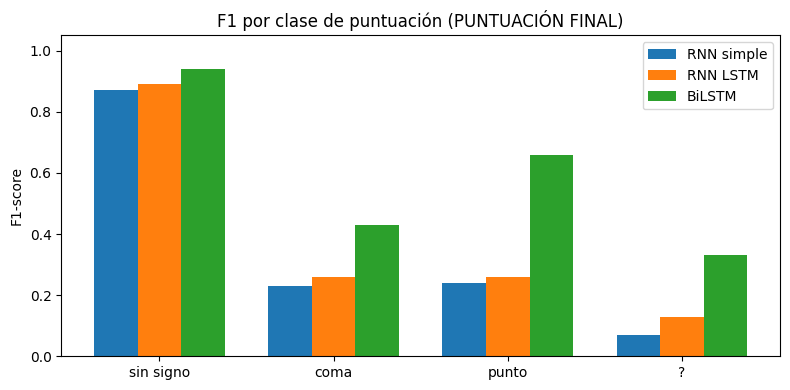

In [30]:
clases = ["sin signo", "coma", "punto", "?"]
x = np.arange(len(clases))
width = 0.25

# F1 por clase - PUNTUACIÓN FINAL
f1_rnn    = [0.87, 0.23, 0.24, 0.07]  # RNN simple
f1_lstm   = [0.89, 0.26, 0.26, 0.13]  # RNN LSTM
f1_bilstm = [0.94, 0.43, 0.66, 0.33]  # BiLSTM

plt.figure(figsize=(8, 4))
plt.bar(x - width, f1_rnn,    width, label="RNN simple")
plt.bar(x,         f1_lstm,   width, label="RNN LSTM")
plt.bar(x + width, f1_bilstm, width, label="BiLSTM")

plt.xticks(x, clases)
plt.ylim(0, 1.05)
plt.ylabel("F1-score")
plt.title("F1 por clase de puntuación (PUNTUACIÓN FINAL)")
plt.legend()
plt.tight_layout()
plt.show()

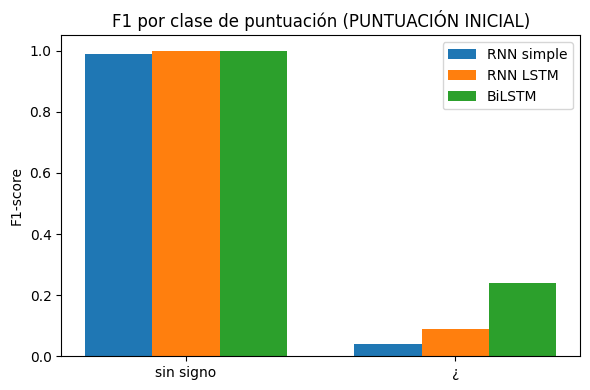

In [31]:
clases = ["sin signo", "¿"]
x = np.arange(len(clases))
width = 0.25

# F1 por clase - PUNTUACIÓN INICIAL
f1_rnn    = [0.99, 0.04]  # RNN simple
f1_lstm   = [1.00, 0.09]  # RNN LSTM
f1_bilstm = [1.00, 0.24]  # BiLSTM

plt.figure(figsize=(6, 4))
plt.bar(x - width, f1_rnn,    width, label="RNN simple")
plt.bar(x,         f1_lstm,   width, label="RNN LSTM")
plt.bar(x + width, f1_bilstm, width, label="BiLSTM")

plt.xticks(x, clases)
plt.ylim(0, 1.05)
plt.ylabel("F1-score")
plt.title("F1 por clase de puntuación (PUNTUACIÓN INICIAL)")
plt.legend()
plt.tight_layout()
plt.show()

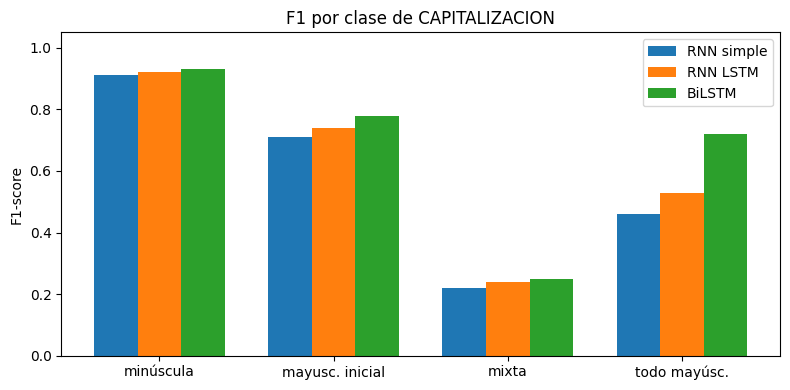

In [32]:
clases = ["minúscula", "mayusc. inicial", "mixta", "todo mayúsc."]
x = np.arange(len(clases))
width = 0.25

# F1 por clase - PUNTUACIÓN FINAL
f1_rnn    = [0.91, 0.71, 0.22, 0.46]  # RNN simple
f1_lstm   = [0.92, 0.74, 0.24, 0.53]  # RNN LSTM
f1_bilstm = [0.93, 0.78, 0.25, 0.72]  # BiLSTM

plt.figure(figsize=(8, 4))
plt.bar(x - width, f1_rnn,    width, label="RNN simple")
plt.bar(x,         f1_lstm,   width, label="RNN LSTM")
plt.bar(x + width, f1_bilstm, width, label="BiLSTM")

plt.xticks(x, clases)
plt.ylim(0, 1.05)
plt.ylabel("F1-score")
plt.title("F1 por clase de CAPITALIZACION")
plt.legend()
plt.tight_layout()
plt.show()

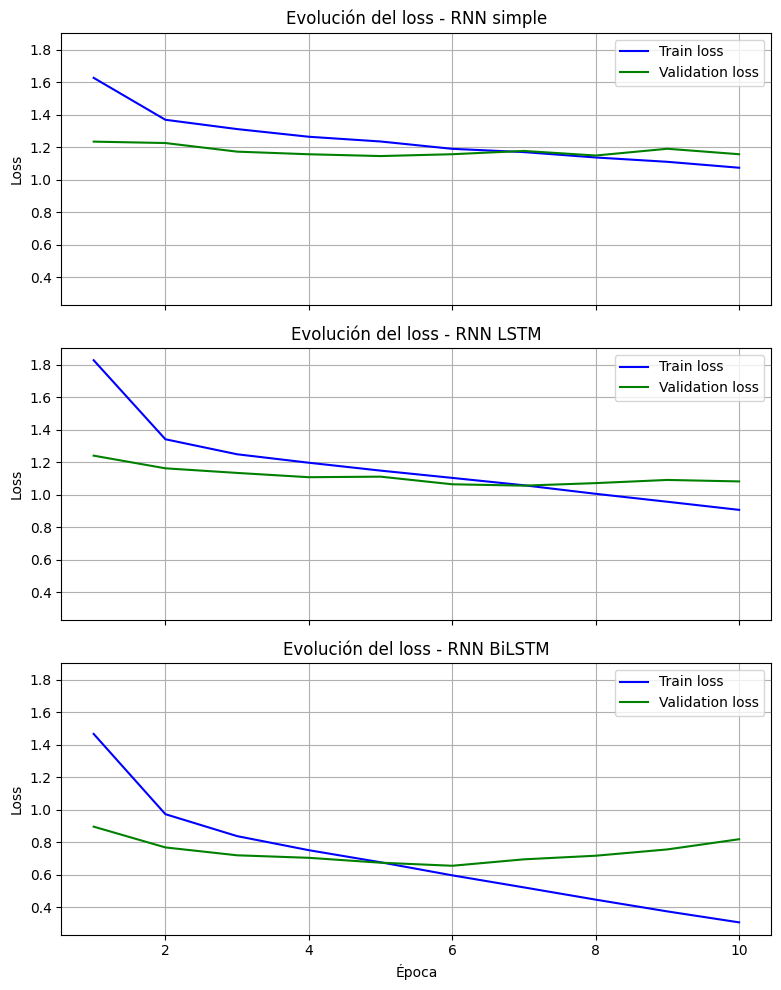

In [33]:
# Todo esto es con 10 epocas

# RNN SIMPLE
rnn_train_losses = [1.6260, 1.3680, 1.3108, 1.2636, 1.2345, 1.1893, 1.1692, 1.1361, 1.1094, 1.0730]
rnn_val_losses   = [1.2336, 1.2250, 1.1720, 1.1559, 1.1448, 1.1561, 1.1764, 1.1481, 1.1897, 1.1561]

# RNN LSTM
lstm_train_losses = [1.8269, 1.3407, 1.2483, 1.1963, 1.1478, 1.1030, 1.0576, 1.0051, 0.9562, 0.9063]
lstm_val_losses   = [1.2398, 1.1619, 1.1336, 1.1072, 1.1106, 1.0637, 1.0553, 1.0709, 1.0904, 1.0813]

# RNN BiLSTM
bilstm_train_losses = [1.4660, 0.9723, 0.8373, 0.7507, 0.6765, 0.5960, 0.5218, 0.4465, 0.3741, 0.3067]
bilstm_val_losses   = [0.8955, 0.7677, 0.7193, 0.7038, 0.6738, 0.6549, 0.6945, 0.7167, 0.7555, 0.8182]

epochs = range(1, 11)

all_losses = (
    rnn_train_losses + rnn_val_losses +
    lstm_train_losses + lstm_val_losses +
    bilstm_train_losses + bilstm_val_losses
)
y_min = min(all_losses)
y_max = max(all_losses)
padding = 0.05 * (y_max - y_min)
y_min -= padding
y_max += padding

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True, sharey=True)

configs = [
    (rnn_train_losses,    rnn_val_losses,    "Evolución del loss - RNN simple"),
    (lstm_train_losses,   lstm_val_losses,   "Evolución del loss - RNN LSTM"),
    (bilstm_train_losses, bilstm_val_losses, "Evolución del loss - RNN BiLSTM"),
]

for ax, (train, val, title) in zip(axes, configs):
    ax.plot(epochs, train, label="Train loss", color="blue")
    ax.plot(epochs, val,   label="Validation loss", color="green")
    ax.set_title(title)
    ax.set_ylabel("Loss")
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Época")

plt.tight_layout()
plt.show()

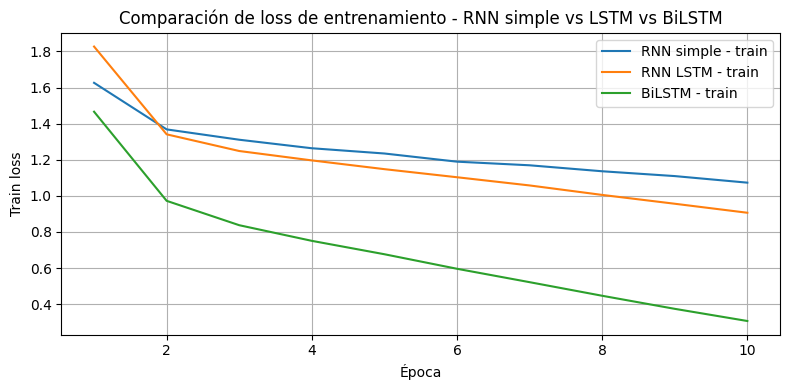

In [34]:
# todo denuevo con 10 epocas

# RNN SIMPLE
rnn_train_losses = [1.6260, 1.3680, 1.3108, 1.2636, 1.2345, 1.1893, 1.1692, 1.1361, 1.1094, 1.0730]

# RNN LSTM
lstm_train_losses = [1.8269, 1.3407, 1.2483, 1.1963, 1.1478, 1.1030, 1.0576, 1.0051, 0.9562, 0.9063]

# RNN BiLSTM
bilstm_train_losses = [1.4660, 0.9723, 0.8373, 0.7507, 0.6765, 0.5960, 0.5218, 0.4465, 0.3741, 0.3067]

epochs = range(1, 11)

all_train = rnn_train_losses + lstm_train_losses + bilstm_train_losses
y_min = min(all_train)
y_max = max(all_train)
padding = 0.05 * (y_max - y_min)
y_min -= padding
y_max += padding

plt.figure(figsize=(8, 4))
plt.plot(epochs, rnn_train_losses,    label="RNN simple - train",   color="tab:blue")
plt.plot(epochs, lstm_train_losses,   label="RNN LSTM - train",     color="tab:orange")
plt.plot(epochs, bilstm_train_losses, label="BiLSTM - train",       color="tab:green")

plt.title("Comparación de loss de entrenamiento - RNN simple vs LSTM vs BiLSTM")
plt.xlabel("Época")
plt.ylabel("Train loss")
plt.ylim(y_min, y_max)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

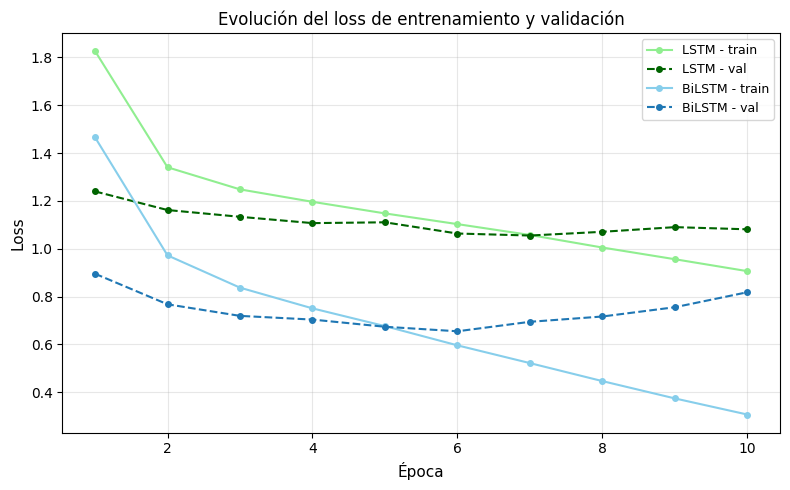

In [35]:
# 10 epocas

# PÉRDIDA LSTM
lstm_train_losses = [1.8269, 1.3407, 1.2483, 1.1963, 1.1478, 1.1030, 1.0576, 1.0051, 0.9562, 0.9063]
lstm_val_losses   = [1.2398, 1.1619, 1.1336, 1.1072, 1.1106, 1.0637, 1.0553, 1.0709, 1.0904, 1.0813]

# PÉRDIDA Bi-LSTM 
bilstm_train_losses = [1.4660, 0.9723, 0.8373, 0.7507, 0.6765, 0.5960, 0.5218, 0.4465, 0.3741, 0.3067]
bilstm_val_losses   = [0.8955, 0.7677, 0.7193, 0.7038, 0.6738, 0.6549, 0.6945, 0.7167, 0.7555, 0.8182]

epochs = range(1, 11)

all_losses = (
    lstm_train_losses + lstm_val_losses +
    bilstm_train_losses + bilstm_val_losses
)
y_min = min(all_losses)
y_max = max(all_losses)
padding = 0.05 * (y_max - y_min)
y_min -= padding
y_max += padding

plt.figure(figsize=(8, 5))

# ----- LSTM -----
plt.plot(
    epochs, lstm_train_losses,
    label="LSTM - train",
    linewidth=1.5,
    marker="o",
    markersize=4,
    color="lightgreen",
)
plt.plot(
    epochs, lstm_val_losses,
    label="LSTM - val",
    linewidth=1.5,
    linestyle="--",
    marker="o",
    markersize=4,
    color="darkgreen",
)

# ----- BiLSTM -----
plt.plot(
    epochs, bilstm_train_losses,
    label="BiLSTM - train",
    linewidth=1.5,
    marker="o",
    markersize=4,
    color="skyblue",
)
plt.plot(
    epochs, bilstm_val_losses,
    label="BiLSTM - val",
    linewidth=1.5,
    linestyle="--",
    marker="o",
    markersize=4,
    color="tab:blue",
)

plt.title("Evolución del loss de entrenamiento y validación", fontsize=12)
plt.xlabel("Época", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.ylim(y_min, y_max)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

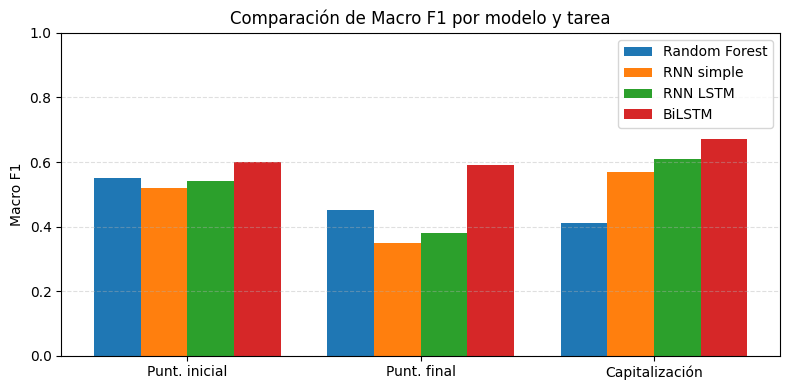

In [36]:
# F1 macro por modelo y tarea
tasks = ["Punt. inicial", "Punt. final", "Capitalización"]
x = np.arange(len(tasks))  # [0, 1, 2]

# Valores de F1 (macro) para cada modelo
f1_rf     = [0.55, 0.45, 0.41]
f1_rnn    = [0.52, 0.35, 0.57]
f1_lstm   = [0.54, 0.38, 0.61]
f1_bilstm = [0.60, 0.59, 0.67]

width = 0.2

plt.figure(figsize=(8, 4))

plt.bar(x - 1.5*width, f1_rf,     width, label="Random Forest")
plt.bar(x - 0.5*width, f1_rnn,    width, label="RNN simple")
plt.bar(x + 0.5*width, f1_lstm,   width, label="RNN LSTM")
plt.bar(x + 1.5*width, f1_bilstm, width, label="BiLSTM")

plt.xticks(x, tasks)
plt.ylim(0, 1.0)
plt.ylabel("Macro F1")
plt.title("Comparación de Macro F1 por modelo y tarea")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

---
# Performance en el held_out (conjunto de control)
Veamos como anda aquel que consideramos nuestro mejor modelo, **Bi-LSTM**, con sus mejores hiperparámetros (dentro de lo que llegamo a probar), en el conjunto de control que separamos al inicio.

In [37]:
# Embeddings control
guardar_embeddings_pickle(df_held, embeddings_matrix, 'embeddings_control.pkl')
embeddings_control = cargamos_embeddings_pickle('embeddings_control.pkl')

y_control = preparamos_etiquetas_dict(df_held)
control_collate = partial(collate_fn_separado,
                           embeddings_dicc=embeddings_control,
                           etiquetas_dict=y_control)

batch_size = 32

control_loader = DataLoader(
    list(embeddings_control.keys()),
    batch_size=batch_size,
    shuffle=False,
    collate_fn=control_collate
)

model = PuntuacionRNN_Bidireccional(
    input_size=768,
    hidden_size=250, 
    num_layers=2,
    cant_clases_punt_inicial=2,
    cant_clases_punt_final=4,
    cant_clases_capitalizacion=4
).to(device)

model.load_state_dict(torch.load('best_model_bilstm.pth', map_location=device))

print(f"\nModelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

control_loss, (preds_punt_ini, targets_punt_ini,
               preds_punt_fin, targets_punt_fin,
               preds_cap, targets_cap) = evaluacion_bidireccional(
    model, control_loader, criterions, device
)

print(f"\n Loss en heldout: {control_loss:.4f}")


# Métricas (ignorando padding)

def filtrar_padding(y_true, y_pred):
    """Filtra las etiquetas de padding (-100) antes de calcular métricas"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != -100
    return y_true[mask], y_pred[mask]

# Puntuación inicial
t_ini_true, t_ini_pred = filtrar_padding(targets_punt_ini, preds_punt_ini)
print("\n--- PUNTUACIÓN INICIAL (HELDOUT) ---")
print(classification_report(
    t_ini_true, t_ini_pred,
    target_names=["sin signo", "¿"]
))

# Puntuación final
t_fin_true, t_fin_pred = filtrar_padding(targets_punt_fin, preds_punt_fin)
print("\n--- PUNTUACIÓN FINAL (HELDOUT) ---")
print(classification_report(
    t_fin_true, t_fin_pred,
    target_names=["sin signo", "coma", "punto", "?"]
))

# Capitalización
t_cap_true, t_cap_pred = filtrar_padding(targets_cap, preds_cap)
print("\n--- CAPITALIZACIÓN (HELDOUT) ---")
print(classification_report(
    t_cap_true, t_cap_pred,
    target_names=["minúscula", "mayúsc. inicial", "mixta", "todo mayúsc."]
))


Modelo creado con 3549010 parámetros

 Loss en heldout: 0.7665

--- PUNTUACIÓN INICIAL (HELDOUT) ---
              precision    recall  f1-score   support

   sin signo       1.00      0.99      1.00     50149
           ¿       0.50      0.87      0.63       350

    accuracy                           0.99     50499
   macro avg       0.75      0.93      0.81     50499
weighted avg       1.00      0.99      0.99     50499


--- PUNTUACIÓN FINAL (HELDOUT) ---
              precision    recall  f1-score   support

   sin signo       0.99      0.90      0.94     46479
        coma       0.28      0.76      0.40      2106
       punto       0.55      0.67      0.60      1599
           ?       0.31      0.55      0.40       315

    accuracy                           0.88     50499
   macro avg       0.53      0.72      0.59     50499
weighted avg       0.94      0.88      0.91     50499


--- CAPITALIZACIÓN (HELDOUT) ---
                 precision    recall  f1-score   support

      mi

---
# Conclusiones finales
Como podemos observar en el classification report de nuestro conjunto de control, nuestro mejor modelo parecería estar andando bastante bien, como esperabamos según nuestro conjunto de validación. El F1 para la puntuación inicial y final es más alto cuando no hay ningún signo, lo cual es esperable porque es lo que ocurre en la gran mayoría de tokens.


---
# Predicciones:
Realizamos las predicciones con nuestro mejor modelo (Bi-LSTM) para las instancias que se nos dieron: (si se quiere correr se debe entrenar el modelo antes para que funcione)

Para poder predecir otro texto se debe llamar a la entrada de texto tokenizado en minusculas datos_test.csv

In [38]:
datos_test = pd.read_csv("datos_test.csv", keep_default_na=False)
model = BertModel.from_pretrained("bert-base-multilingual-cased")
model.eval()
embeddings_matrix = model.get_input_embeddings().weight.detach().numpy()

# Embeddings control
guardar_embeddings_pickle(datos_test, embeddings_matrix, 'embeddings_datos_test.pkl')
embeddings_datos_test = cargamos_embeddings_pickle('embeddings_datos_test.pkl')

def collate_fn_pred(batch, embeddings_dicc):
    #embeddings y longitudes
    items_embedding = [embeddings_dicc[k] for k in batch]
    lengths = torch.LongTensor([item['length'] for item in items_embedding])
    
    #tensores paddeados
    embeddings_padded = torch.zeros(len(items_embedding), lengths.max().item(), 768)
    
    for i in range(len(items_embedding)):
        seq_len = items_embedding[i]['length']
        embeddings_padded[i, :seq_len] = items_embedding[i]['embeddings']
    
    return {
        'embeddings': embeddings_padded,
        'lengths': lengths,
        'instancia_ids': batch  
    }

collate_test = partial(collate_fn_pred, embeddings_dicc=embeddings_datos_test)

test_loader = DataLoader(
    list(embeddings_datos_test.keys()),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_test
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = PuntuacionRNN_Bidireccional(  
    input_size=768,
    hidden_size=250, 
    num_layers=2,
    cant_clases_punt_inicial=2,
    cant_clases_punt_final=4,
    cant_clases_capitalizacion=4
).to(device)

# Cargamos pesos entrenados
model.load_state_dict(torch.load('best_model_bilstm.pth', map_location=device))
model.eval()  

print(f" Modelo cargado con {sum(p.numel() for p in model.parameters())} parámetros")

predicciones = {
        'punt_inicial': [],
        'punt_final': [],
        'capitalizacion': [],
        'instancia_ids': [],
        'lengths': []
    }

with torch.no_grad():
    for batch in test_loader:
        emb = batch["embeddings"].to(device)
        lengths = batch["lengths"]
        instancia_ids = batch['instancia_ids']

        #pasada forward
        logits_ini, logits_fin, logits_cap = model(emb, lengths)

        #obtenemos predicciones
        preds_ini = torch.argmax(logits_ini, dim=-1)
        preds_fin = torch.argmax(logits_fin, dim=-1)
        preds_cap = torch.argmax(logits_cap, dim=-1)

        # Guardamos predicciones por instancia
        for i, inst_id in enumerate(instancia_ids):
            seq_len = lengths[i].item()
            # Extraemos solo la parte real (sin padding)
            predicciones['punt_inicial'].append(preds_ini[i, :seq_len].cpu().numpy())
            predicciones['punt_final'].append(preds_fin[i, :seq_len].cpu().numpy())
            predicciones['capitalizacion'].append(preds_cap[i, :seq_len].cpu().numpy())
            predicciones['instancia_ids'].append(inst_id)
            predicciones['lengths'].append(seq_len)

res = []
# Mapeos inversos (números a símbolos)
inv_map_ini = {0: "", 1: "¿"}
inv_map_fin = {0: "", 1: ",", 2: ".", 3: "?"}

for i, inst_id in enumerate(predicciones['instancia_ids']):
    #obtengo tokens originales para esta instancia
    df_inst = datos_test[datos_test['instancia_id'] == inst_id].reset_index(drop=True)
    #obtengo predicciones para esta instancia
    preds_ini_inst = predicciones['punt_inicial'][i]
    preds_fin_inst = predicciones['punt_final'][i]
    preds_cap_inst = predicciones['capitalizacion'][i]
    seq_len = predicciones['lengths'][i]
    for i in range(len(df_inst)):
            fila = {
                'instancia_id': inst_id,
                'token_id': df_inst.loc[i, 'token_id'],
                'token': df_inst.loc[i, 'token'],
                'punt_inicial': inv_map_ini[preds_ini_inst[i]],
                'punt_final': inv_map_fin[preds_fin_inst[i]],
                'capitalización': int(preds_cap_inst[i])
            }
            res.append(fila)
  
df_pred = pd.DataFrame(res)
df_pred.to_csv("predicciones_test.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'datos_test.csv'

Finalmente concluimos (para nuestro trabajo particular):


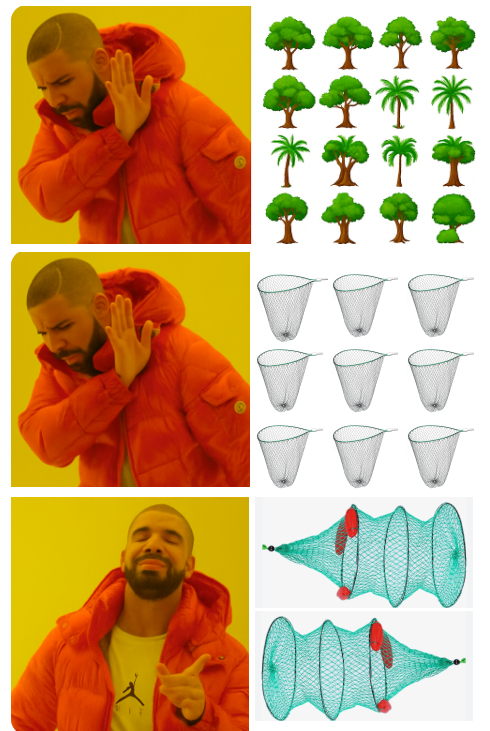